# Embedding Visualisation

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils import process_rw_file
import numpy as np
from utils import (load_graph_from_txt, compute_energy, compute_neighbor_loss_over_records)
import torch

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

# Trees

## Shuffled Numbers

  [] Warning: token '12' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '2' has only 9 occurrences in [0:500] (requested 10)
  [] Warning: token '5' has only 7 occurrences in [0:500] (requested 10)
  [] Warning: token '6' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:500] (requested 10)


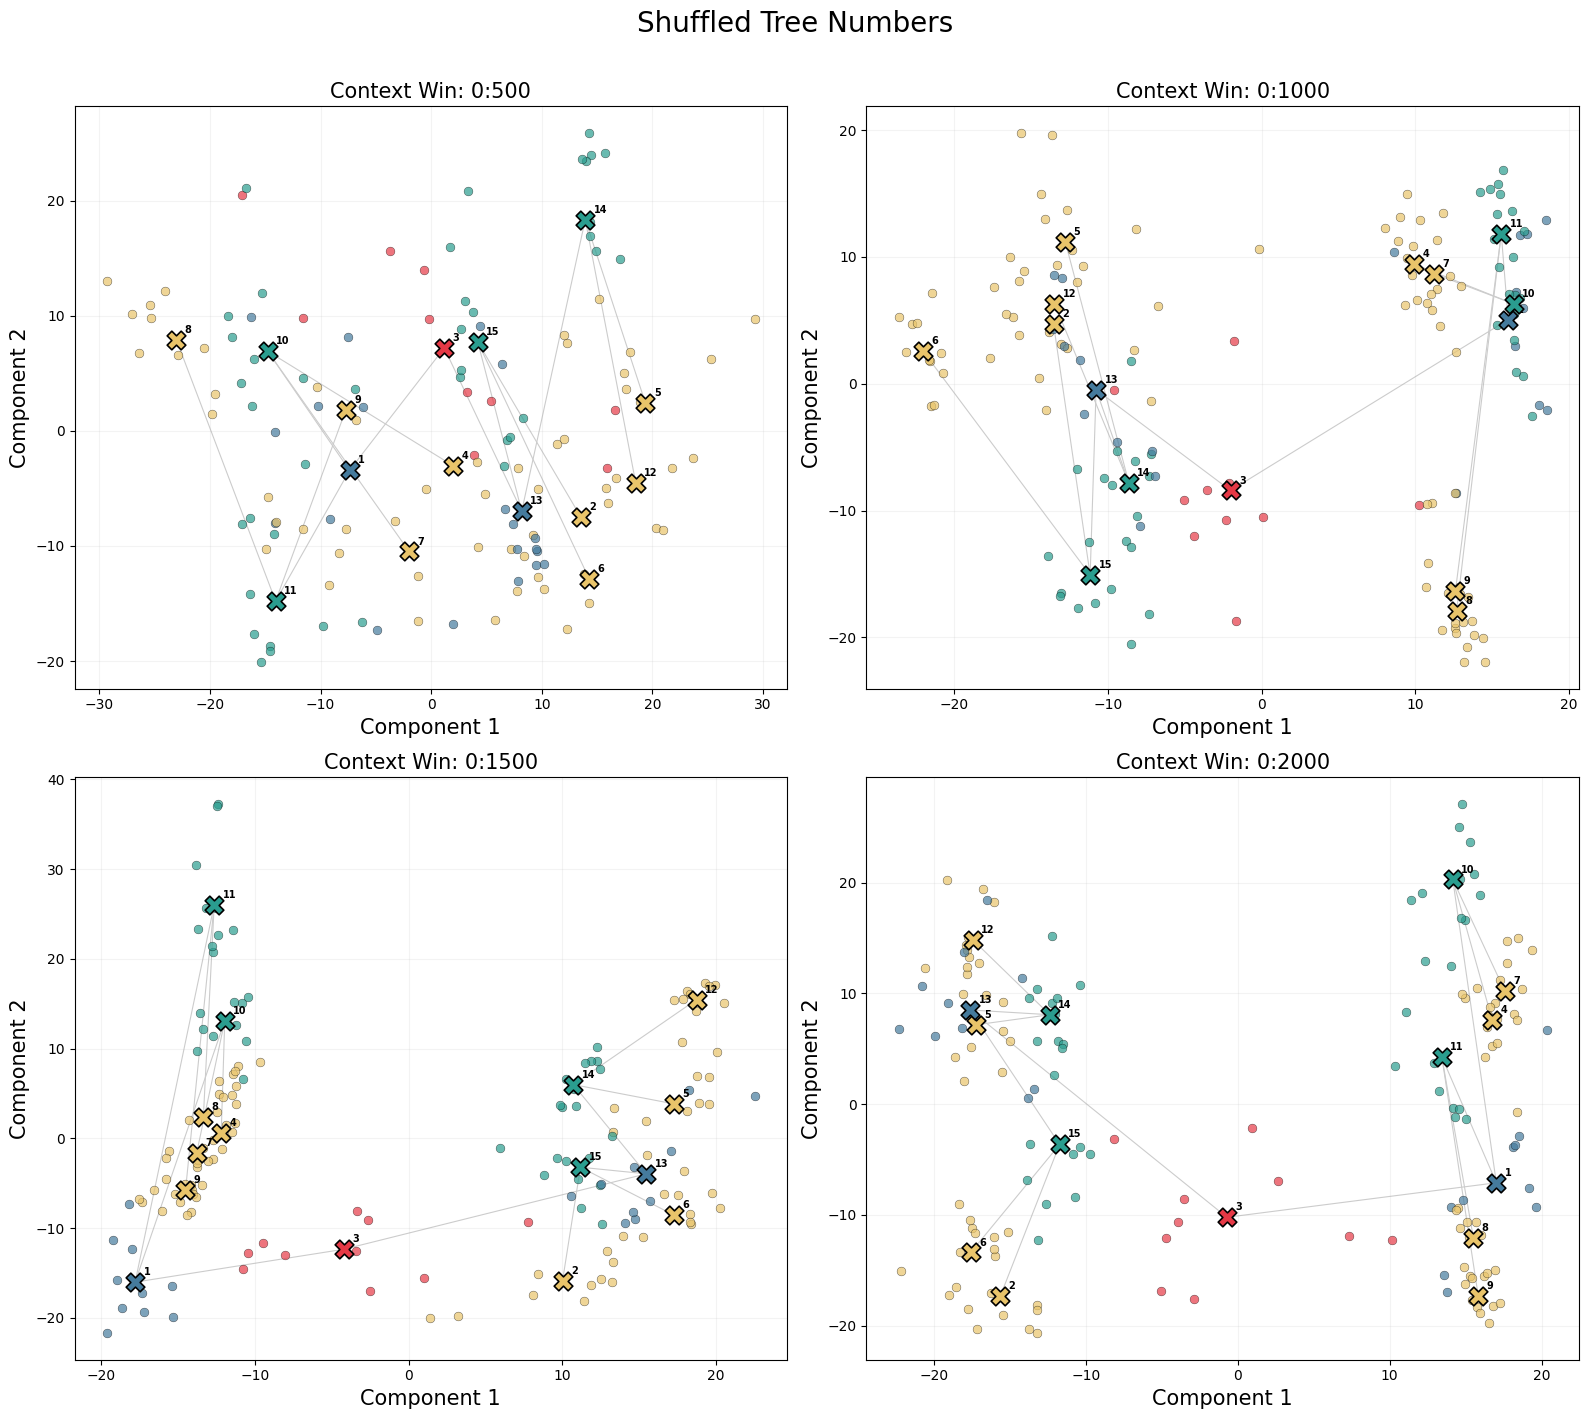

Processing context length: 500
Processing context length: 1000
Processing context length: 1500
Processing context length: 2000


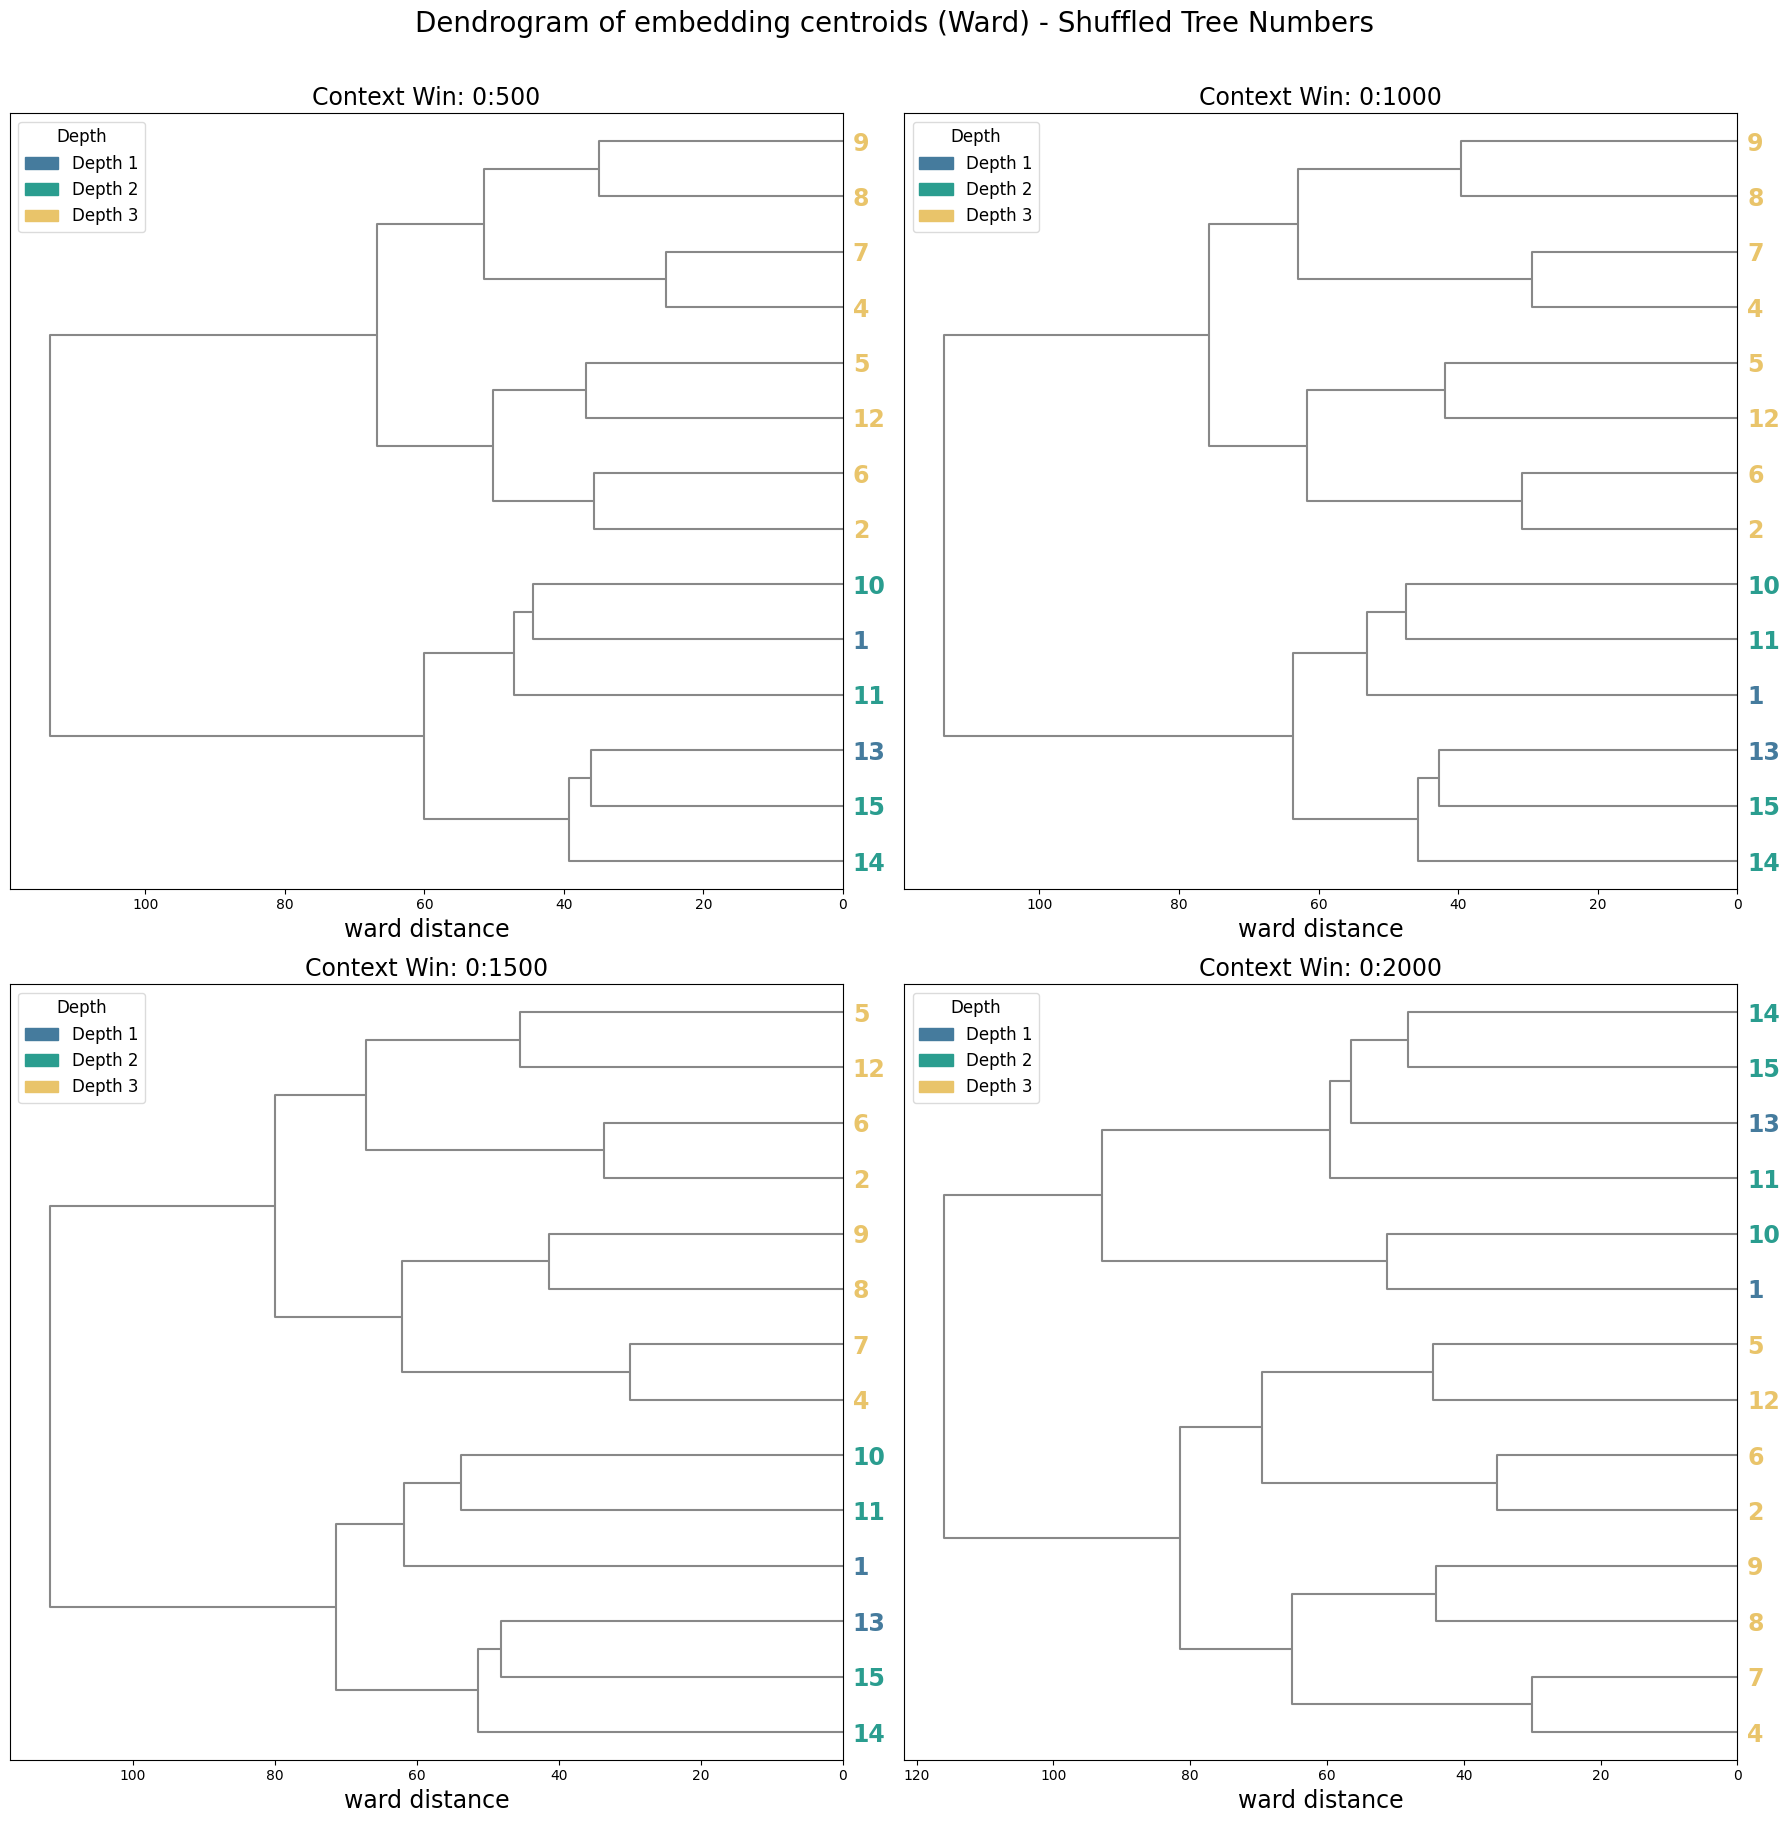

Grid - #nodi: 15 #archi: 14
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '4' has only 5 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '10' has only 5 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '1' has only 1 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '4' has only 7 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '7' has only 2 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '1' has only 1 occurrences in [0:60] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '7' has only 4 occurrences in [0:60] (requested 10)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '1' has only 3 occurrences in [0:80] (requested 10)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '3' has only 1 occurrences in [0:80] (requested 10)
  [ctx=2000, win_

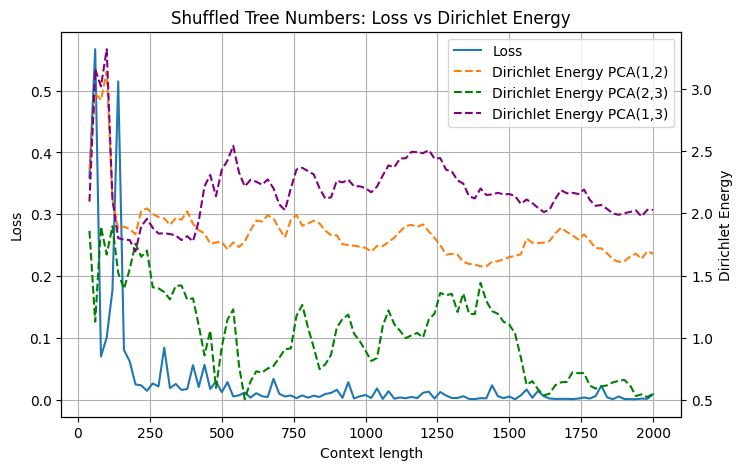

In [17]:
directory = "shuffled_tree_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1500, 2000]

k_last = 10
pc_to_plot = (1, 2)  # PCA components to plot

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")

    mask_layer_l = np.isin(ids_np, ids_layer_l)
    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=k_last, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle(f"Dendrogram of embedding centroids (Ward) - {directory.replace('_', ' ').title()}",
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/dendrogram_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Ordered Numbers

  [] Warning: token '1' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '3' has only 7 occurrences in [0:500] (requested 10)
  [] Warning: token '5' has only 9 occurrences in [0:500] (requested 10)
  [] Warning: token '7' has only 3 occurrences in [0:500] (requested 10)
  [] Warning: token '9' has only 5 occurrences in [0:500] (requested 10)


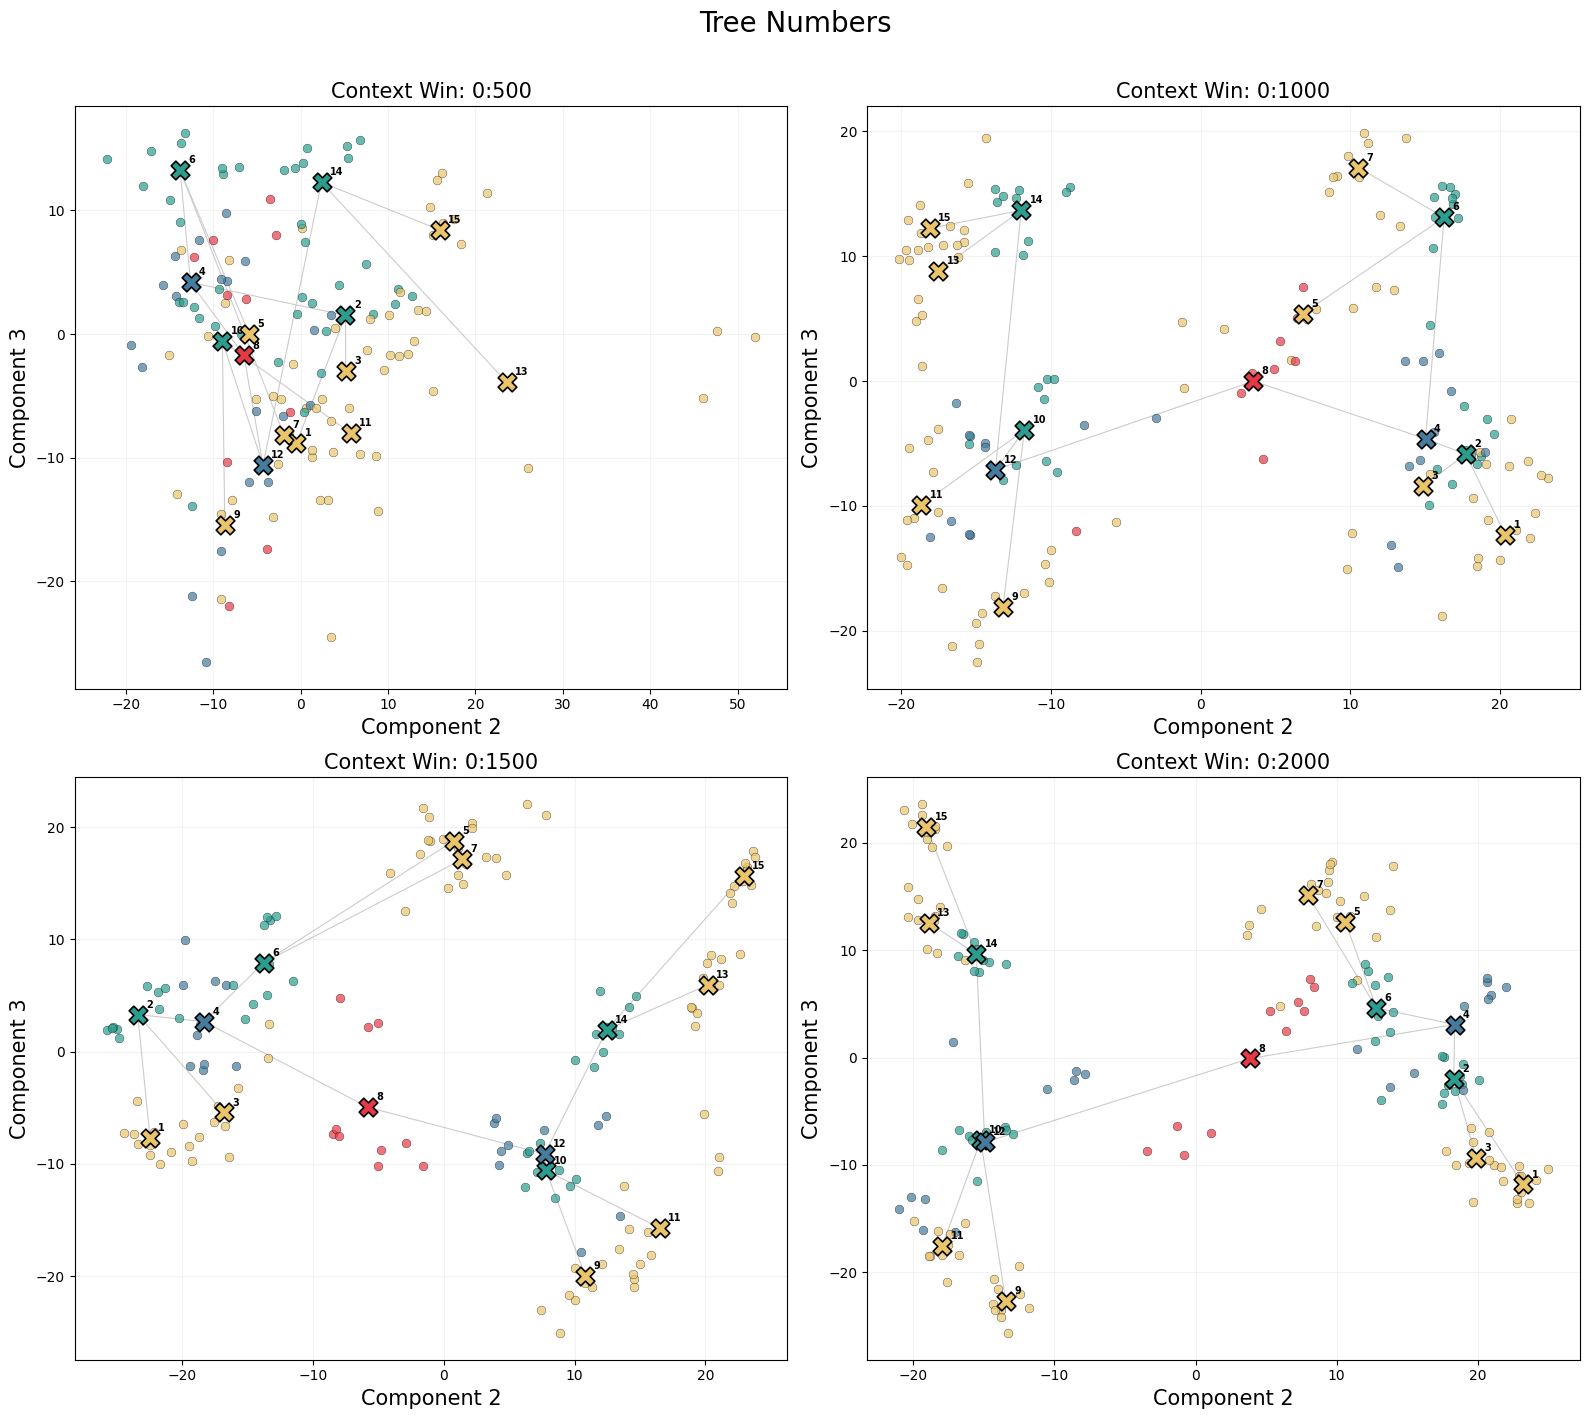

Processing context length: 500
Processing context length: 1000
Processing context length: 1500
Processing context length: 2000


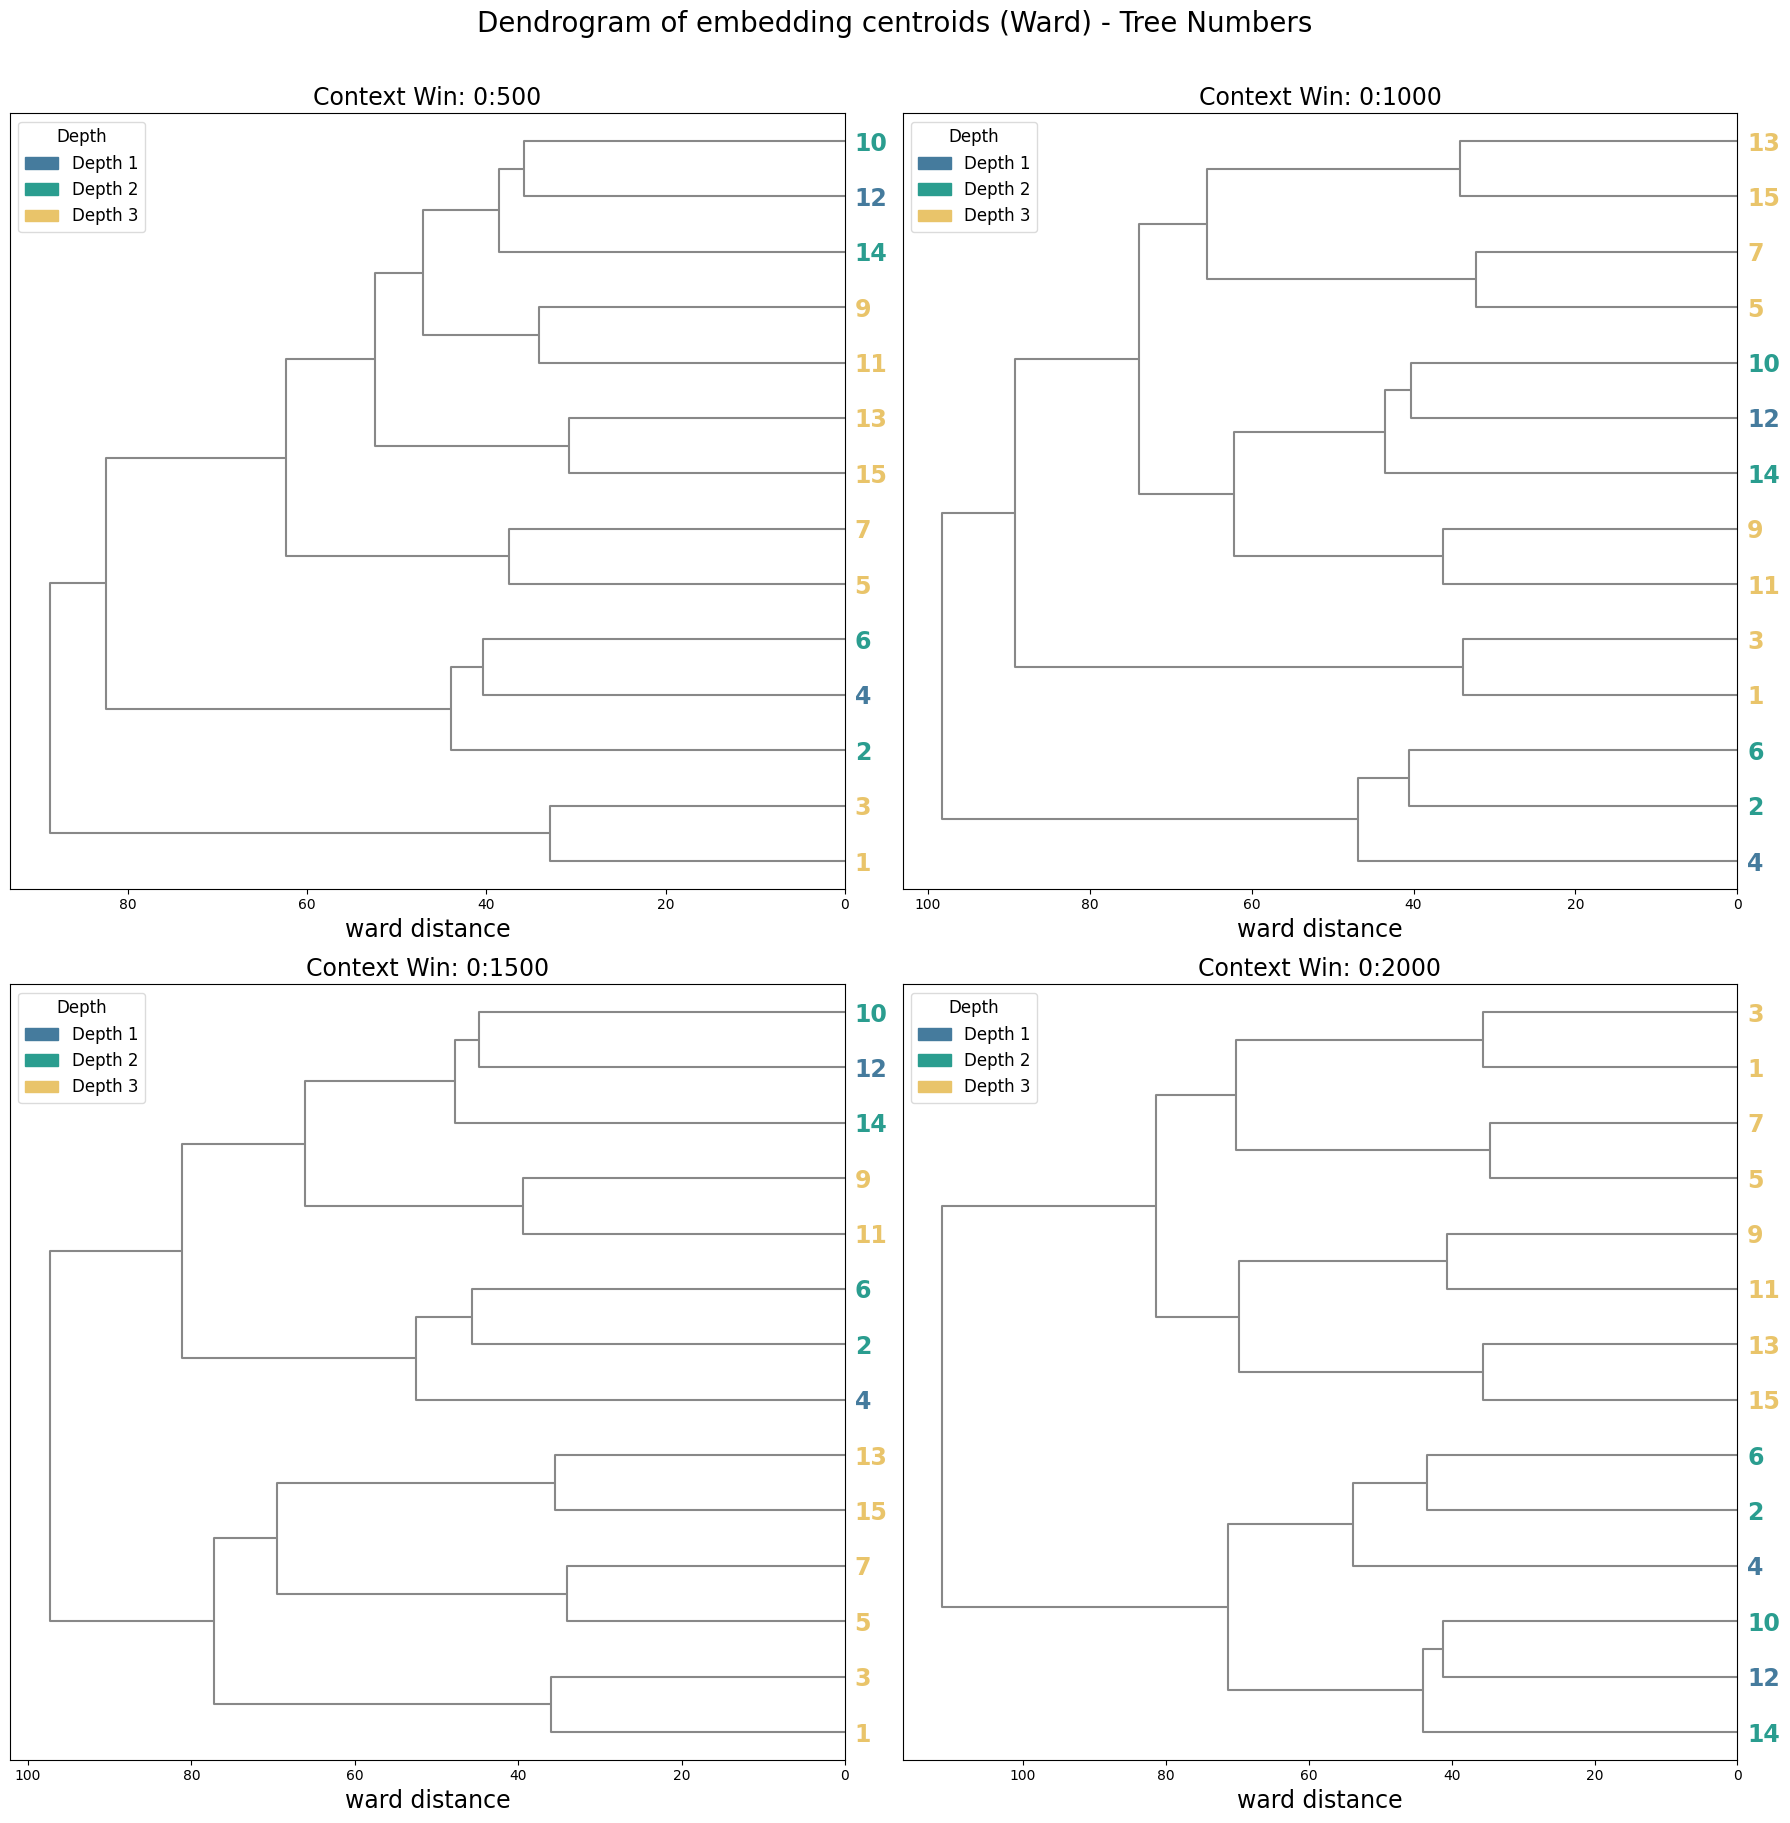

Grid - #nodi: 15 #archi: 14
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 5 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 5 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 2 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '13' has only 7 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '12' has only 1 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '15' has only 4 occurrences in [0:60] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '12' has only 1 occurrences in [0:60] (requested 10)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '15' has only 5 occurrences in [0:80] (requested 10)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '12' has only 3 occurrences in [0:80] (requested 10)
  [ctx=20

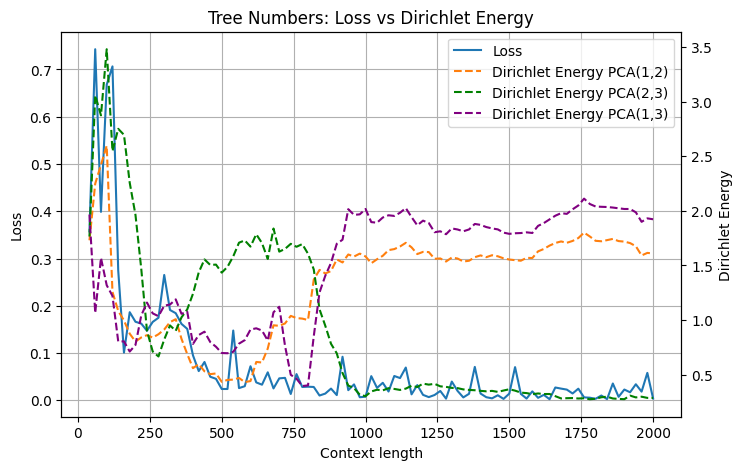

In [18]:
directory = "tree_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1500, 2000]

k_last = 10
pc_to_plot = (1, 2)  # PCA components to plot

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=True)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")

    mask_layer_l = np.isin(ids_np, ids_layer_l)
    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=k_last, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle(f"Dendrogram of embedding centroids (Ward) - {directory.replace('_', ' ').title()}",
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/dendrogram_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    pc1=0,
    pc2=1,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Words

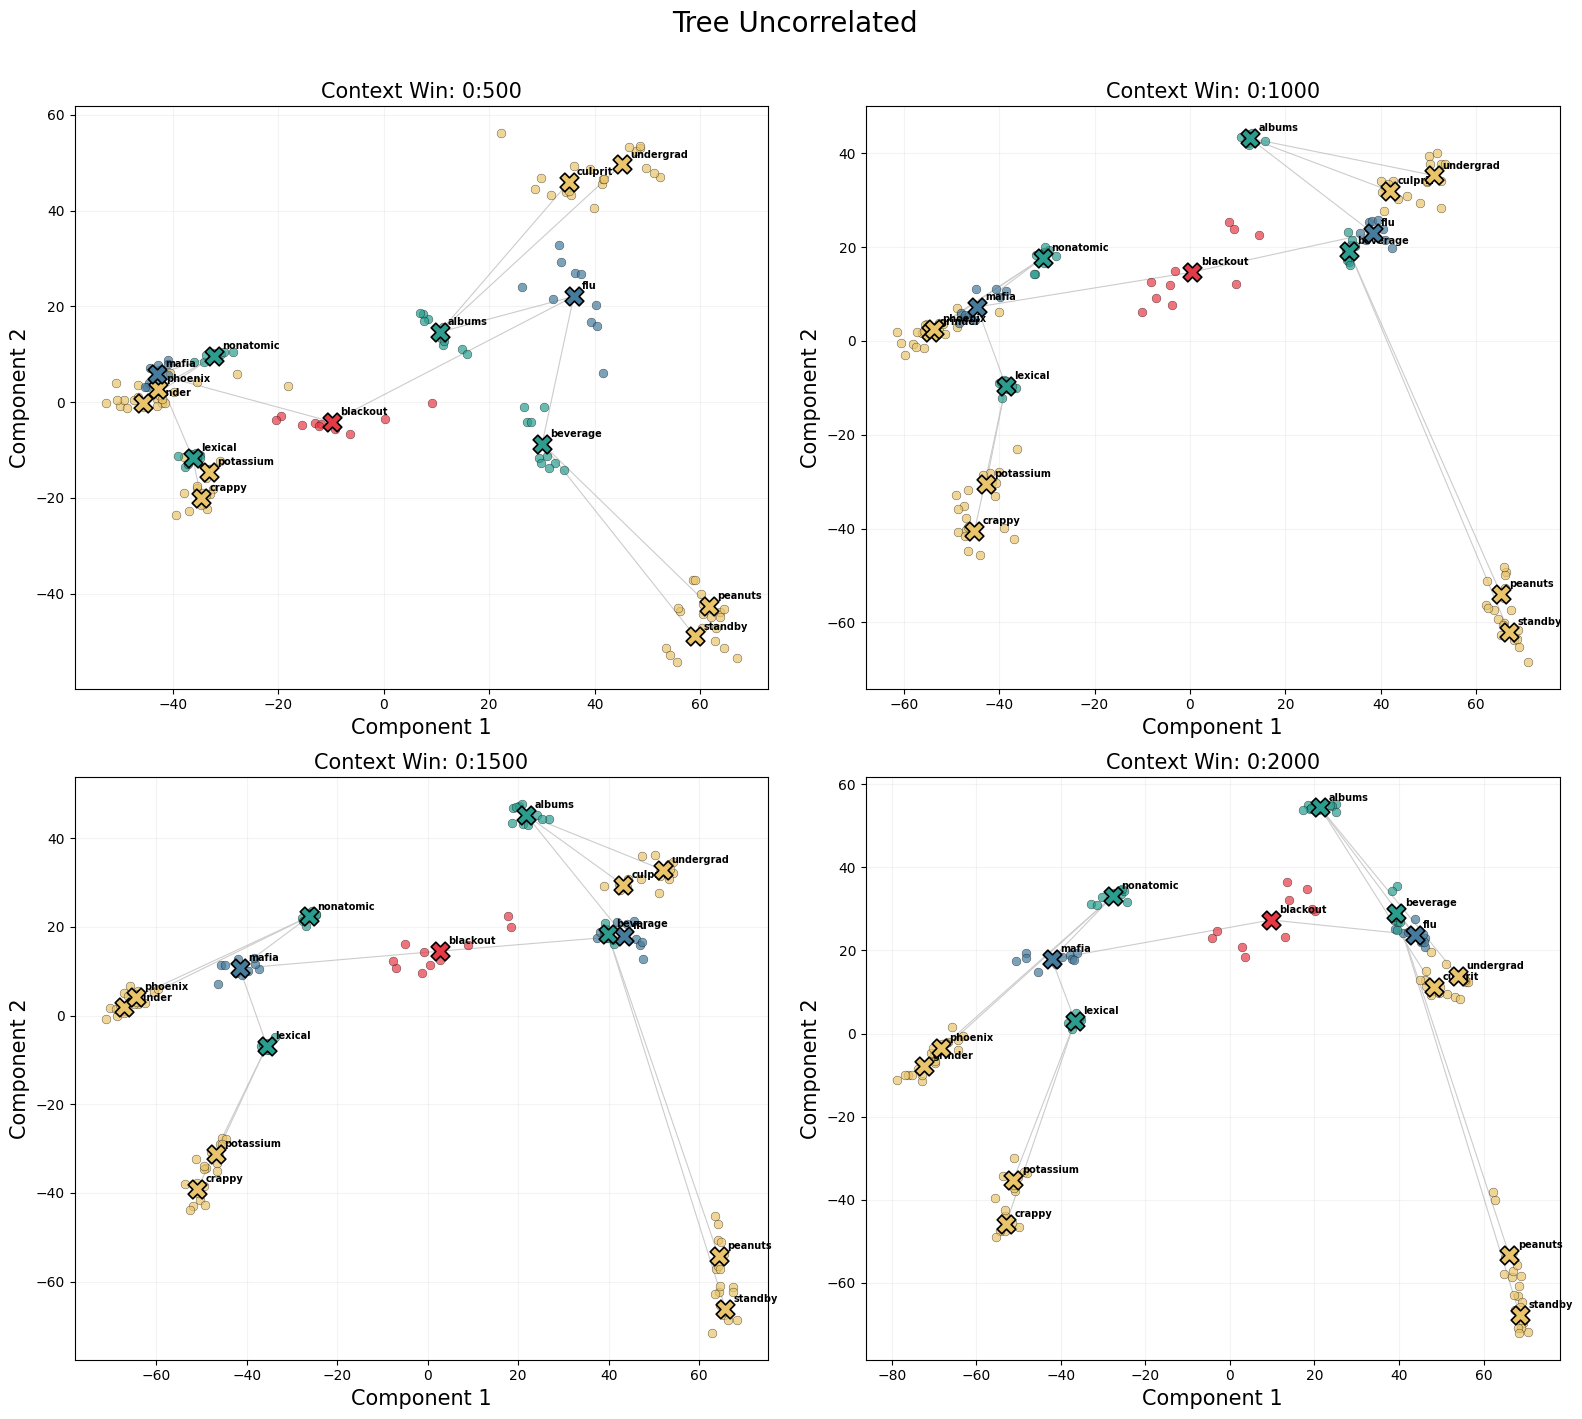

Processing context length: 500
Processing context length: 1000
Processing context length: 1500
Processing context length: 2000


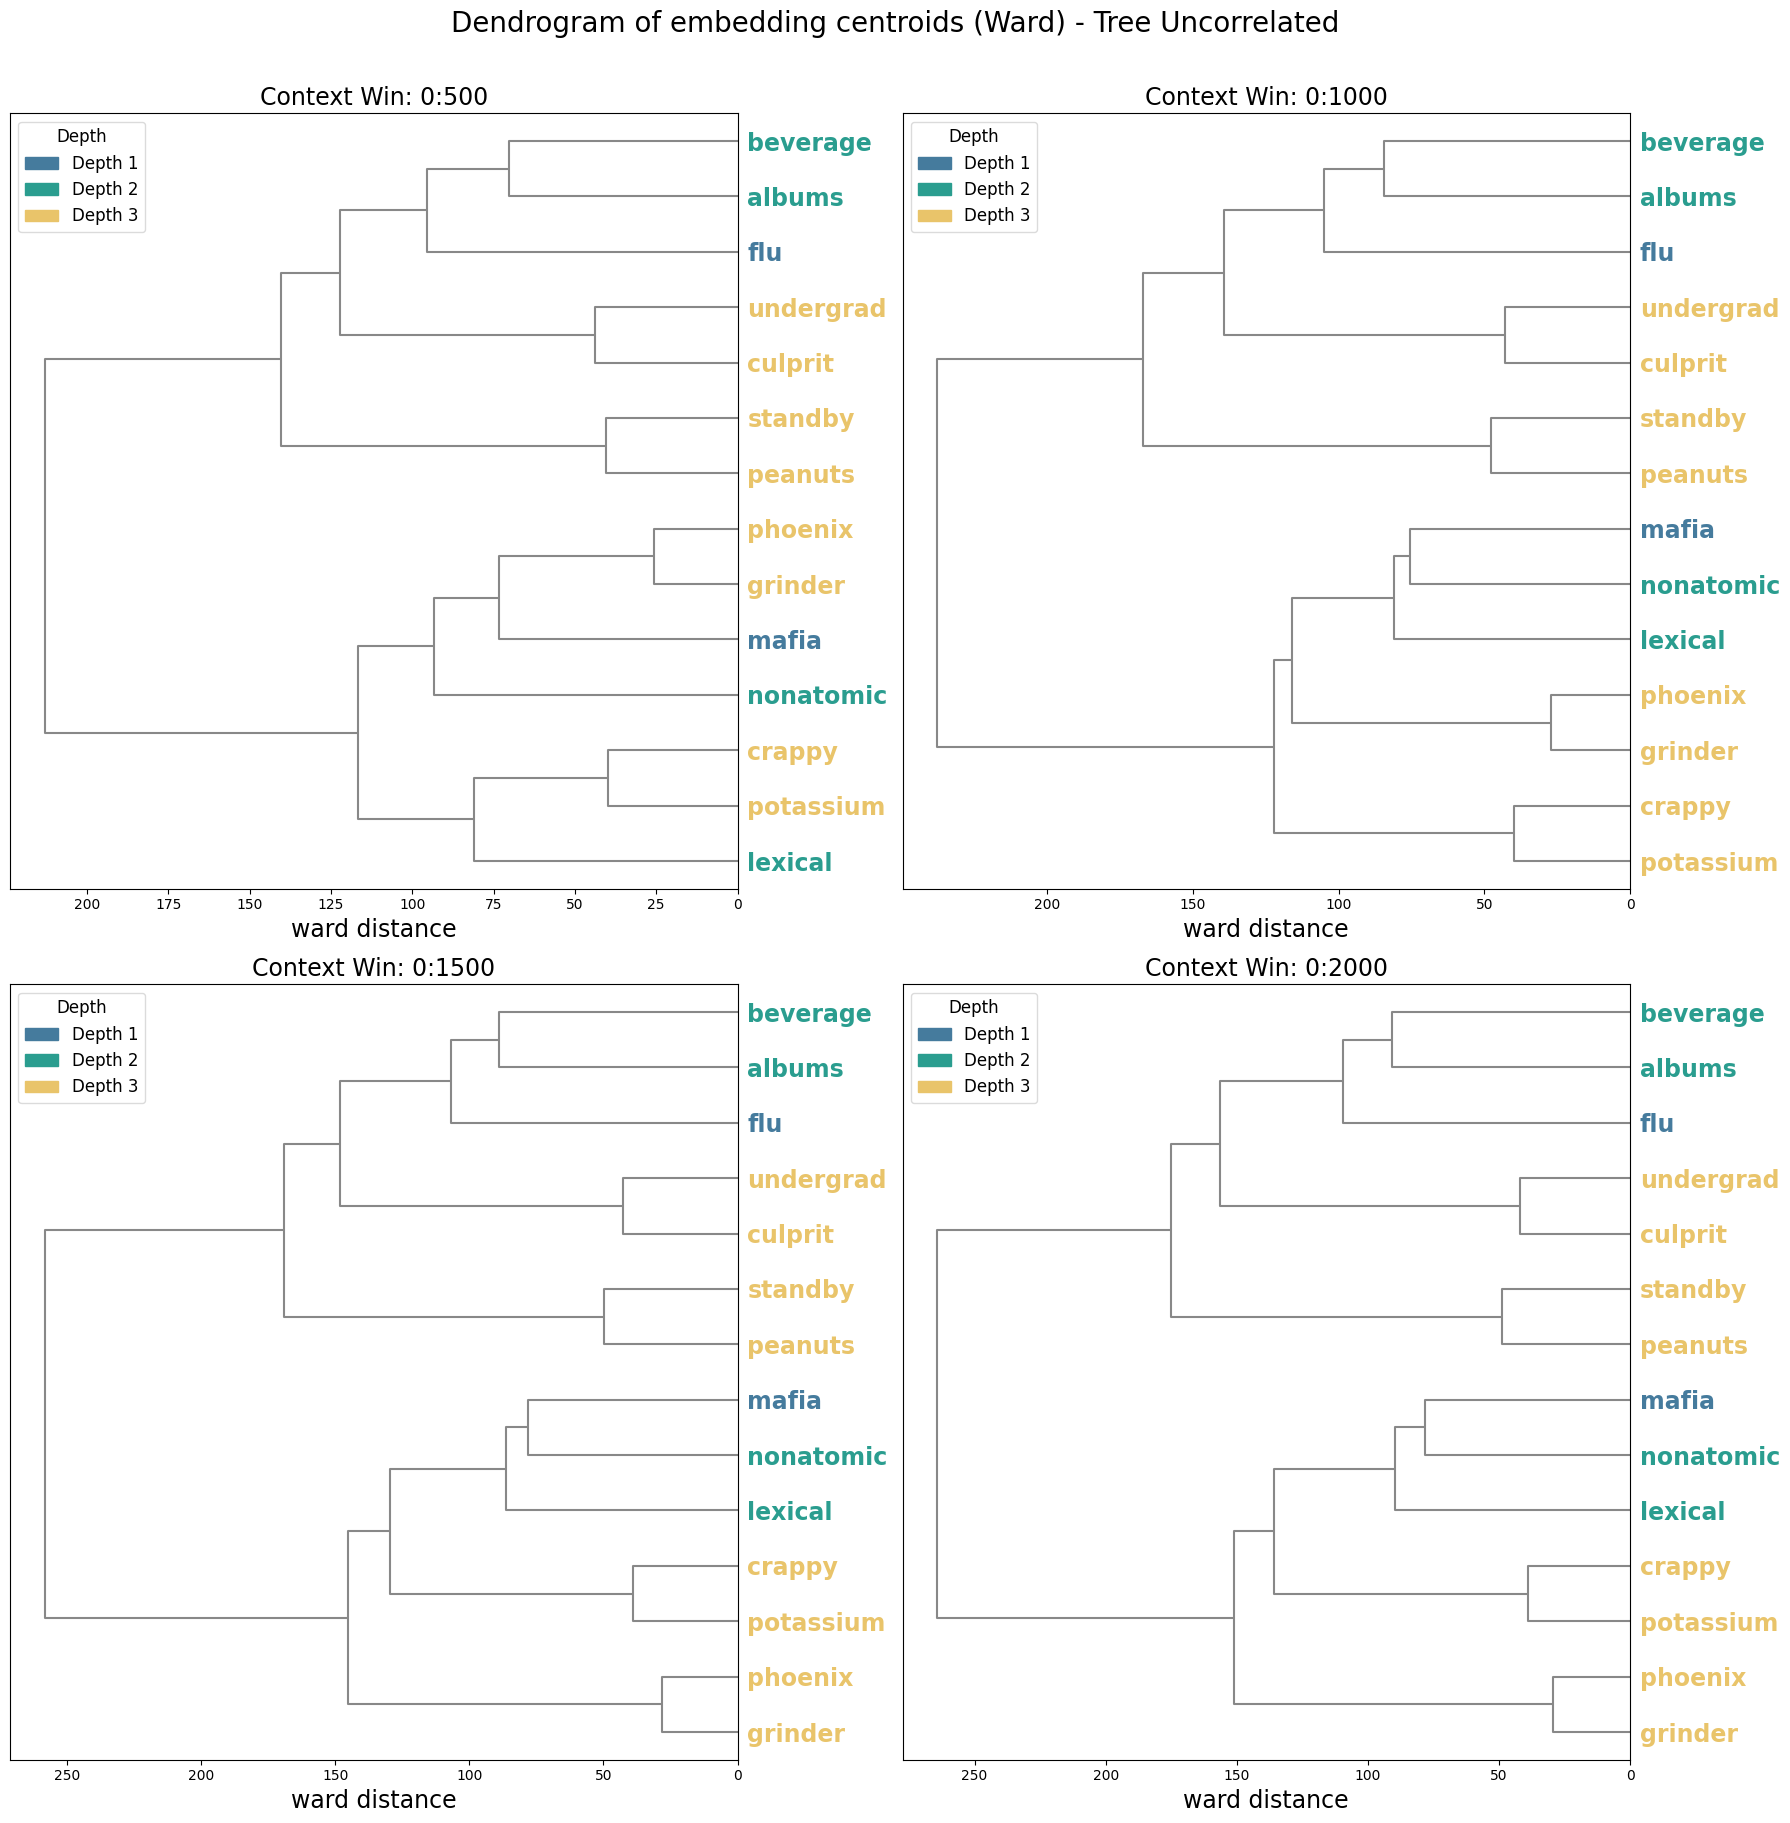

Grid - #nodi: 15 #archi: 14
[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='under')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'flu' has only 1 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'albums' has only 9 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'undergrad' has only 5 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'flu' has only 2 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'culprit' has only 5 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'blackout' has only 2 occurrences in [0:60] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'nonatomic' has only 1 occurrences in [0:60

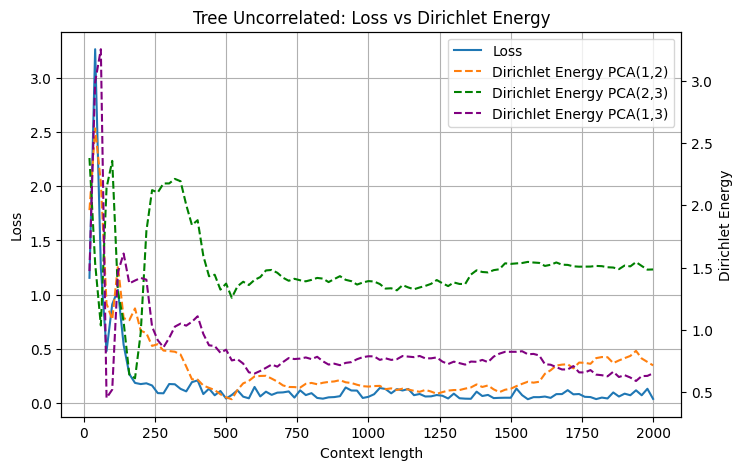

In [19]:
directory = "tree_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1500, 2000]

k_last = 10

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,0:2]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")

    mask_layer_l = np.isin(ids_np, ids_layer_l)
    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=k_last, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle(f"Dendrogram of embedding centroids (Ward) - {directory.replace('_', ' ').title()}",
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/dendrogram_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Days

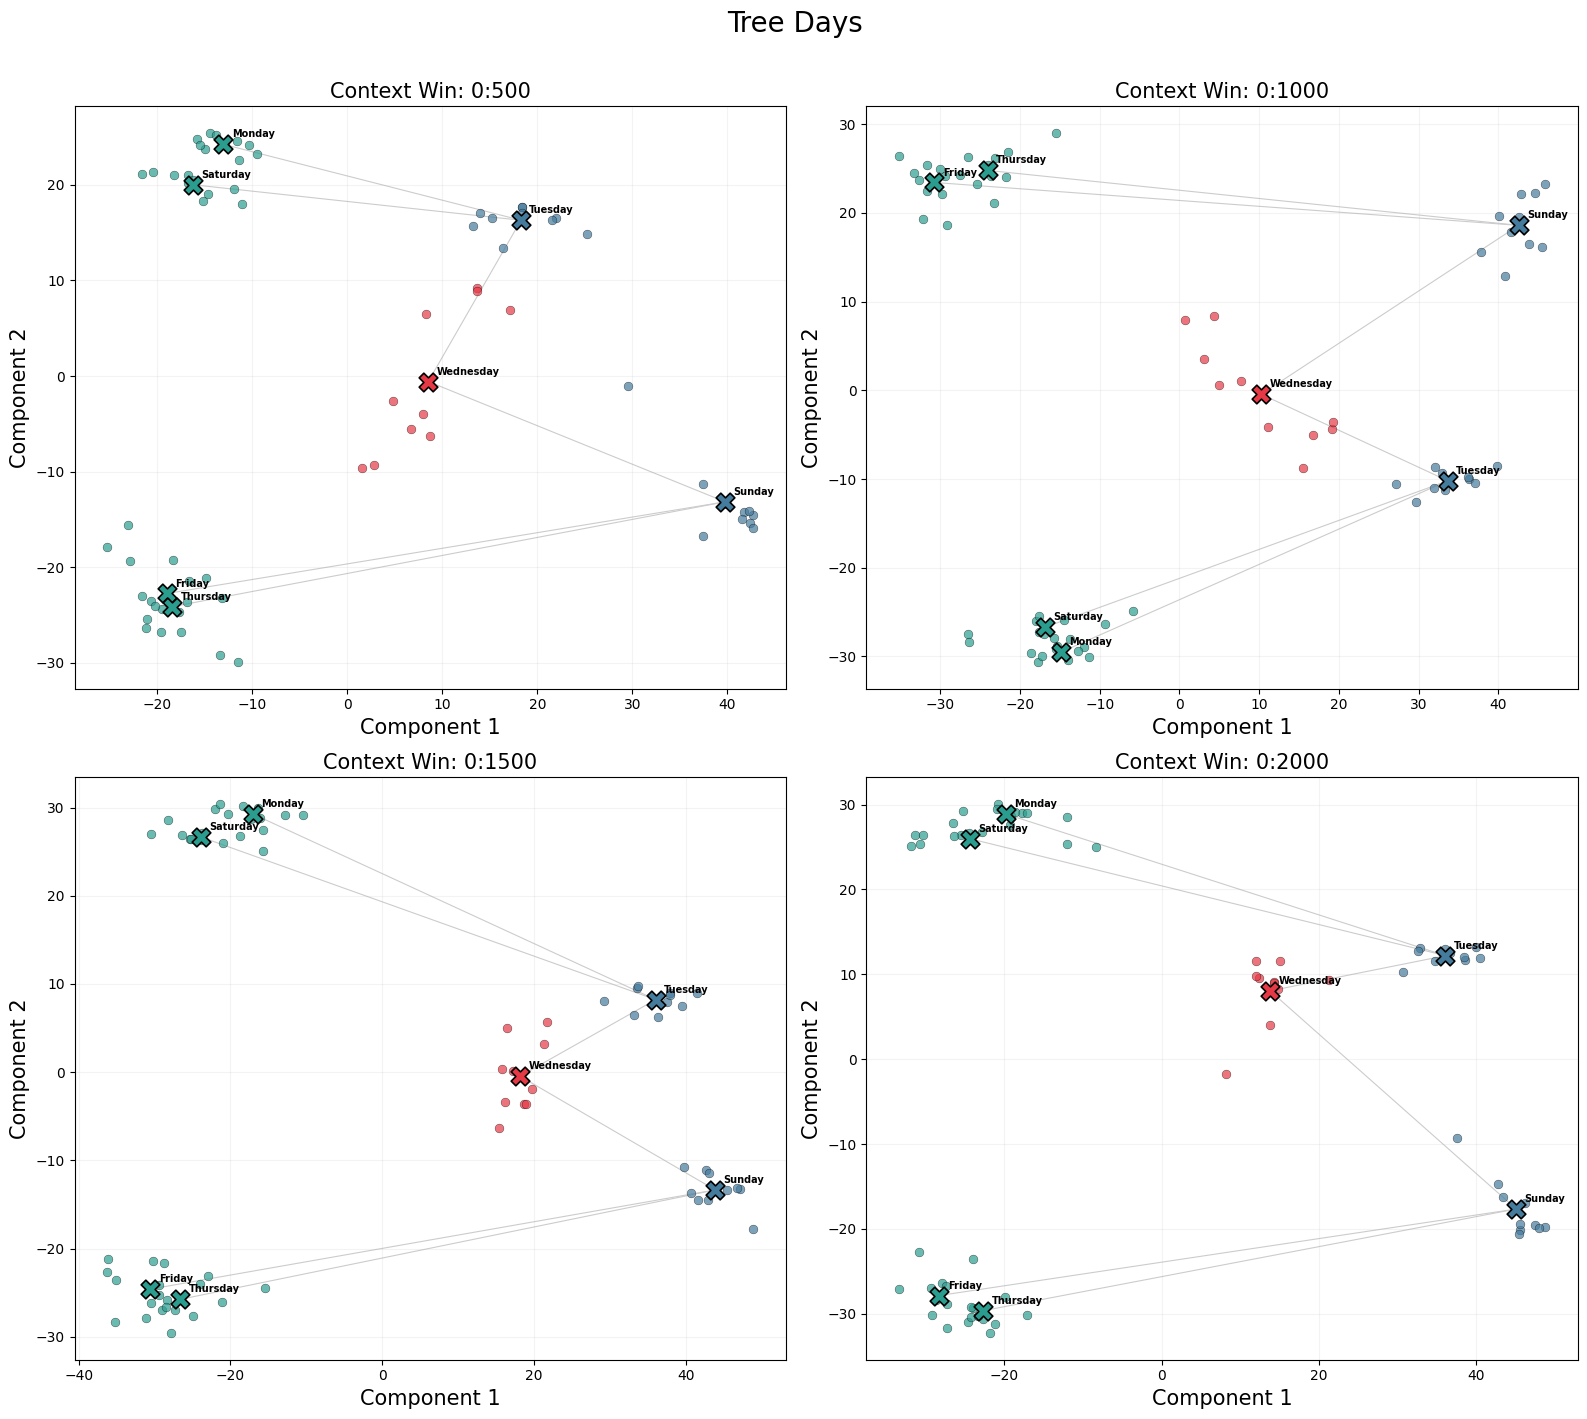

Processing context length: 500
Processing context length: 1000
Processing context length: 1500
Processing context length: 2000


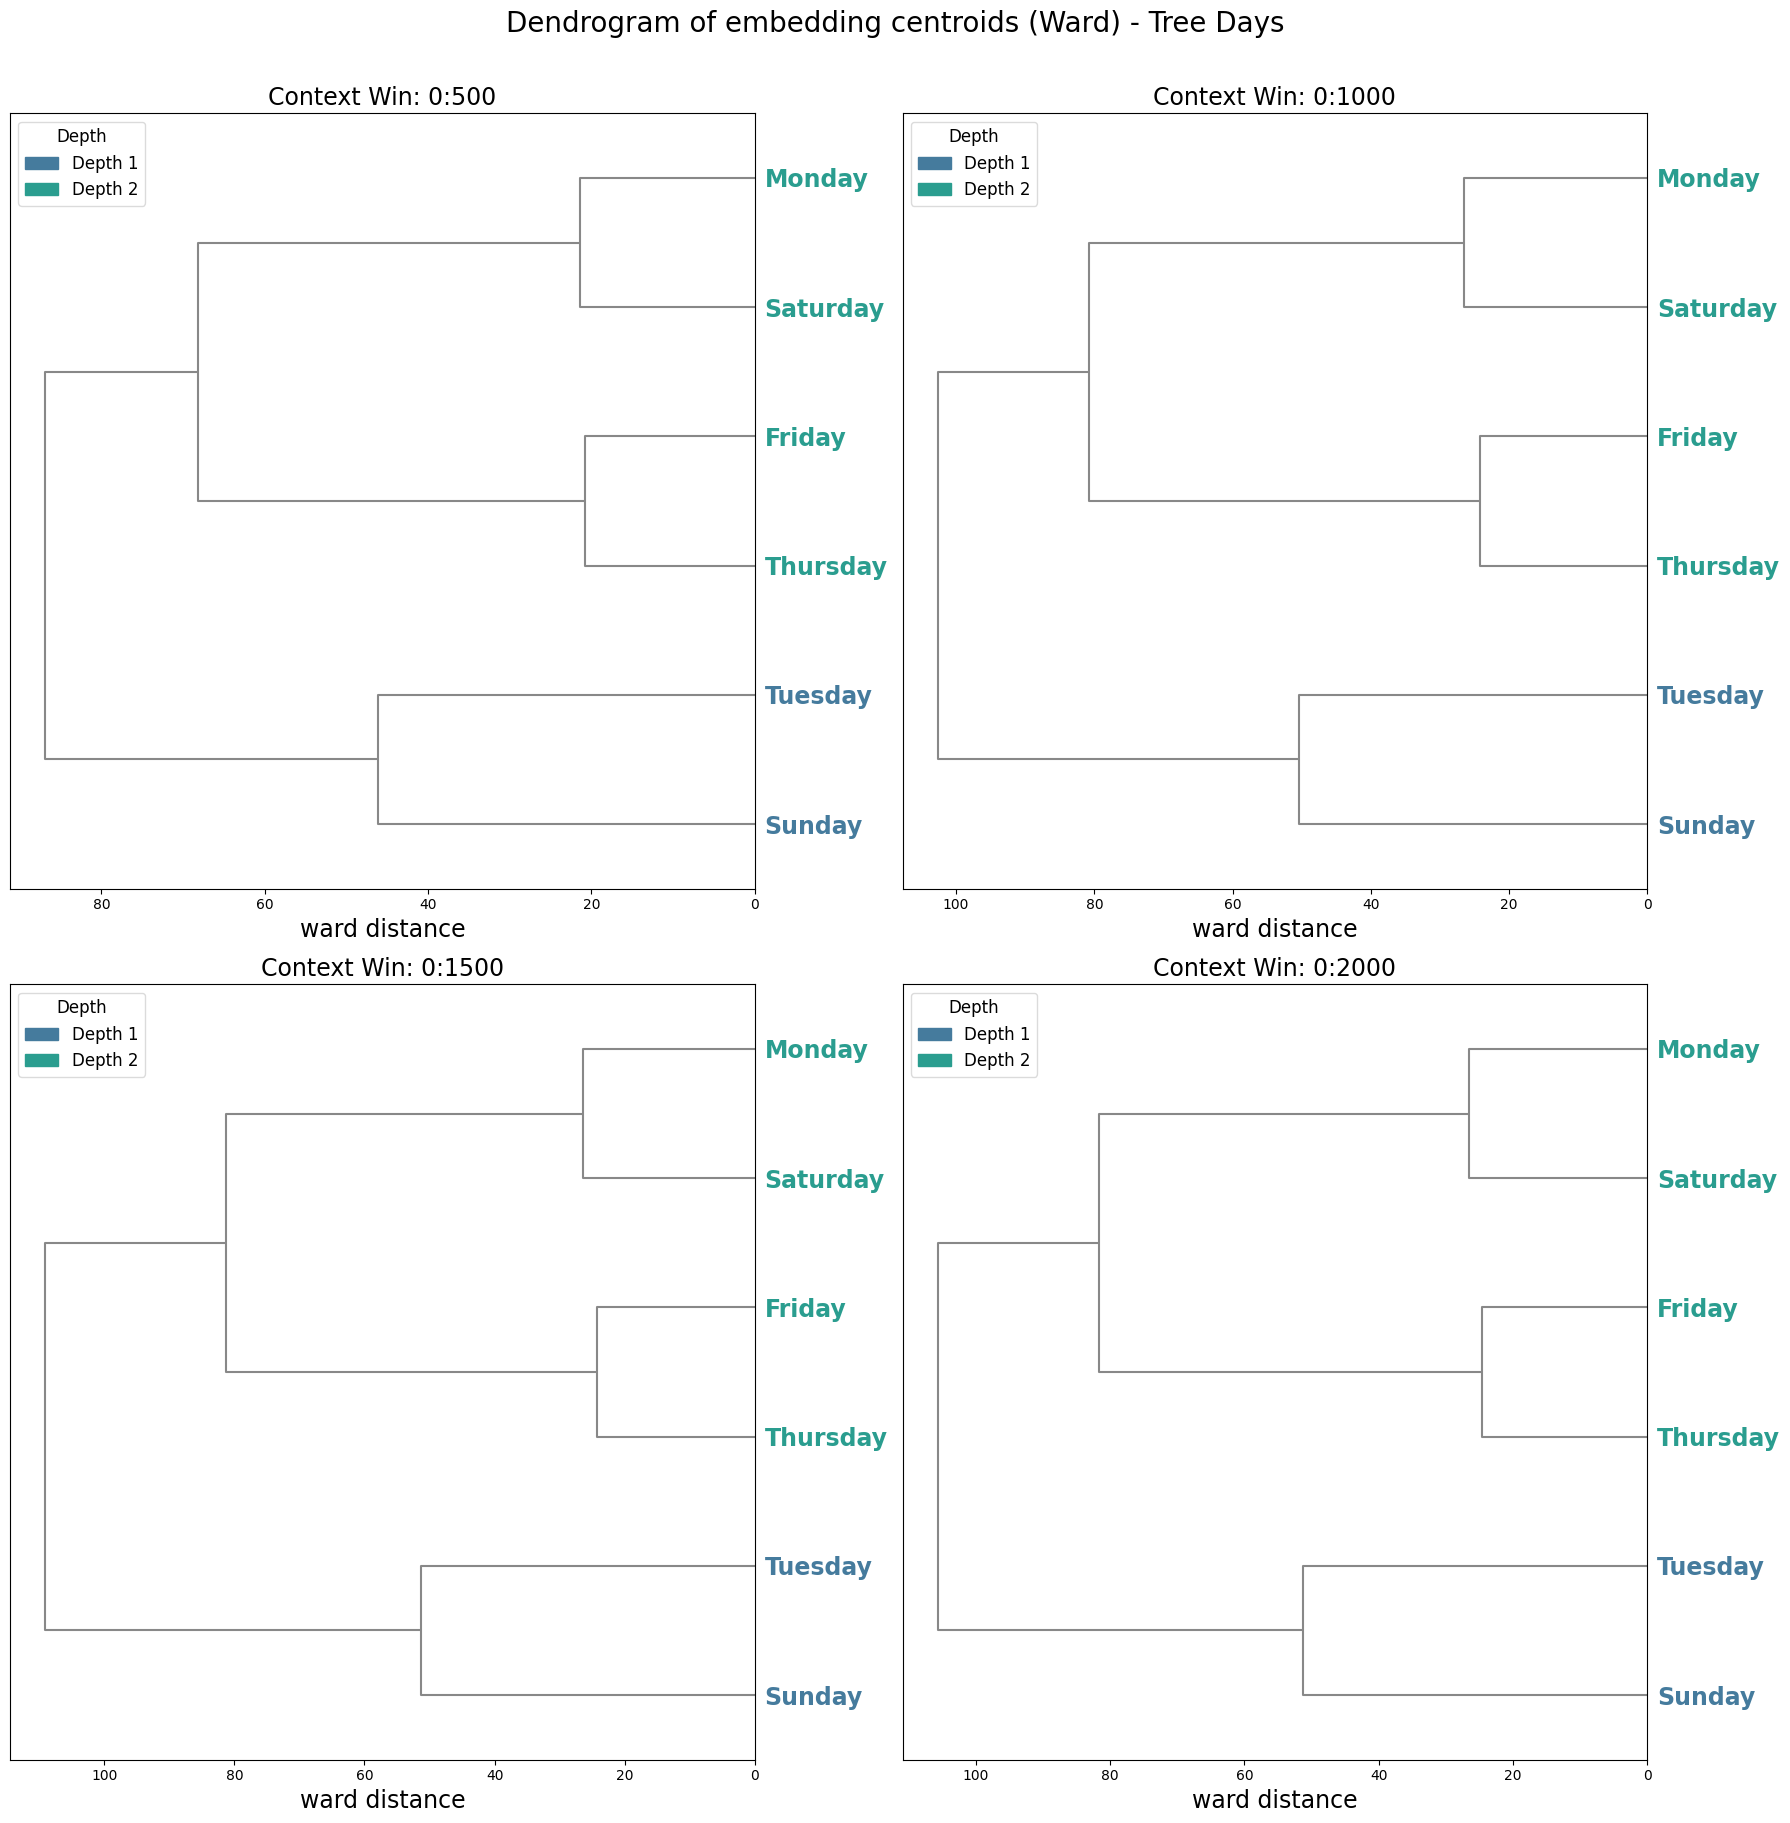

Grid - #nodi: 7 #archi: 6
[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Monday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 5 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 1 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 9 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 3 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Monday' has only 6 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Sunday' has only 1 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token 'Thursday' has only 1 occurrences in [0:60] (requested 10)


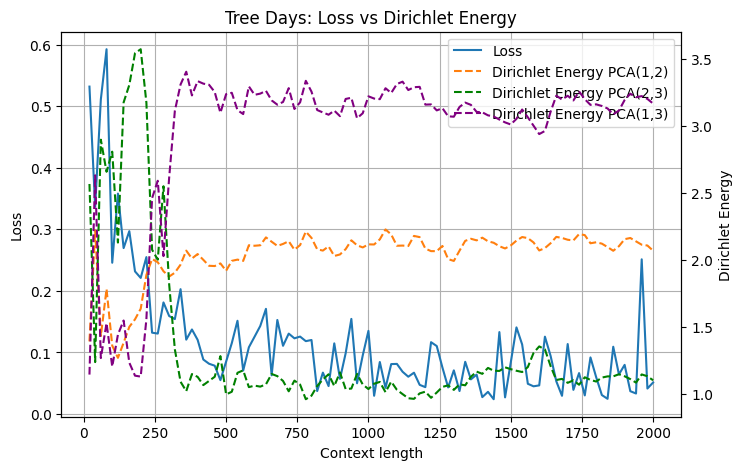

In [20]:
directory = "tree_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "tree"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1500, 2000]

k_last = 10
pc_to_plot = (0, 1)  # PCA components to plot

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# -------------------------------- DENDROGRAM -------------------------------- #

layer = 3 # quale livello dell'albero dendrogrammo
layer2 = 2 # quale livello dell'albero dendrogrammo per i centroidi
layer3 = 1

toks_layer_l = [toks for toks, depth in hp_tree.token_to_group.items() if depth == layer or depth == layer2 or depth == layer3]
ids_layer_l = [hp_tree.word_to_tid[tok] for tok in toks_layer_l]

for ax, win in zip(axes.flat, CTX_LENS):
    print(f"Processing context length: {win}")

    mask_layer_l = np.isin(ids_np, ids_layer_l)
    emb_np = emb_np[mask_layer_l]
    ids_np = ids_np[mask_layer_l]

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, k=k_last, t_end=win)

    centroids_id, centroids_emb = centroids_by_token(filtered_ids, filtered_embs)

    hp_tree.plot_dendrogram_on_points(ax, centroids_id, centroids_emb, title=f"Context Win: 0:{win}", method="ward", max_leaves=50)

fig.suptitle(f"Dendrogram of embedding centroids (Ward) - {directory.replace('_', ' ').title()}",
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/dendrogram_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()
G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

# Grids

## Square Numbers

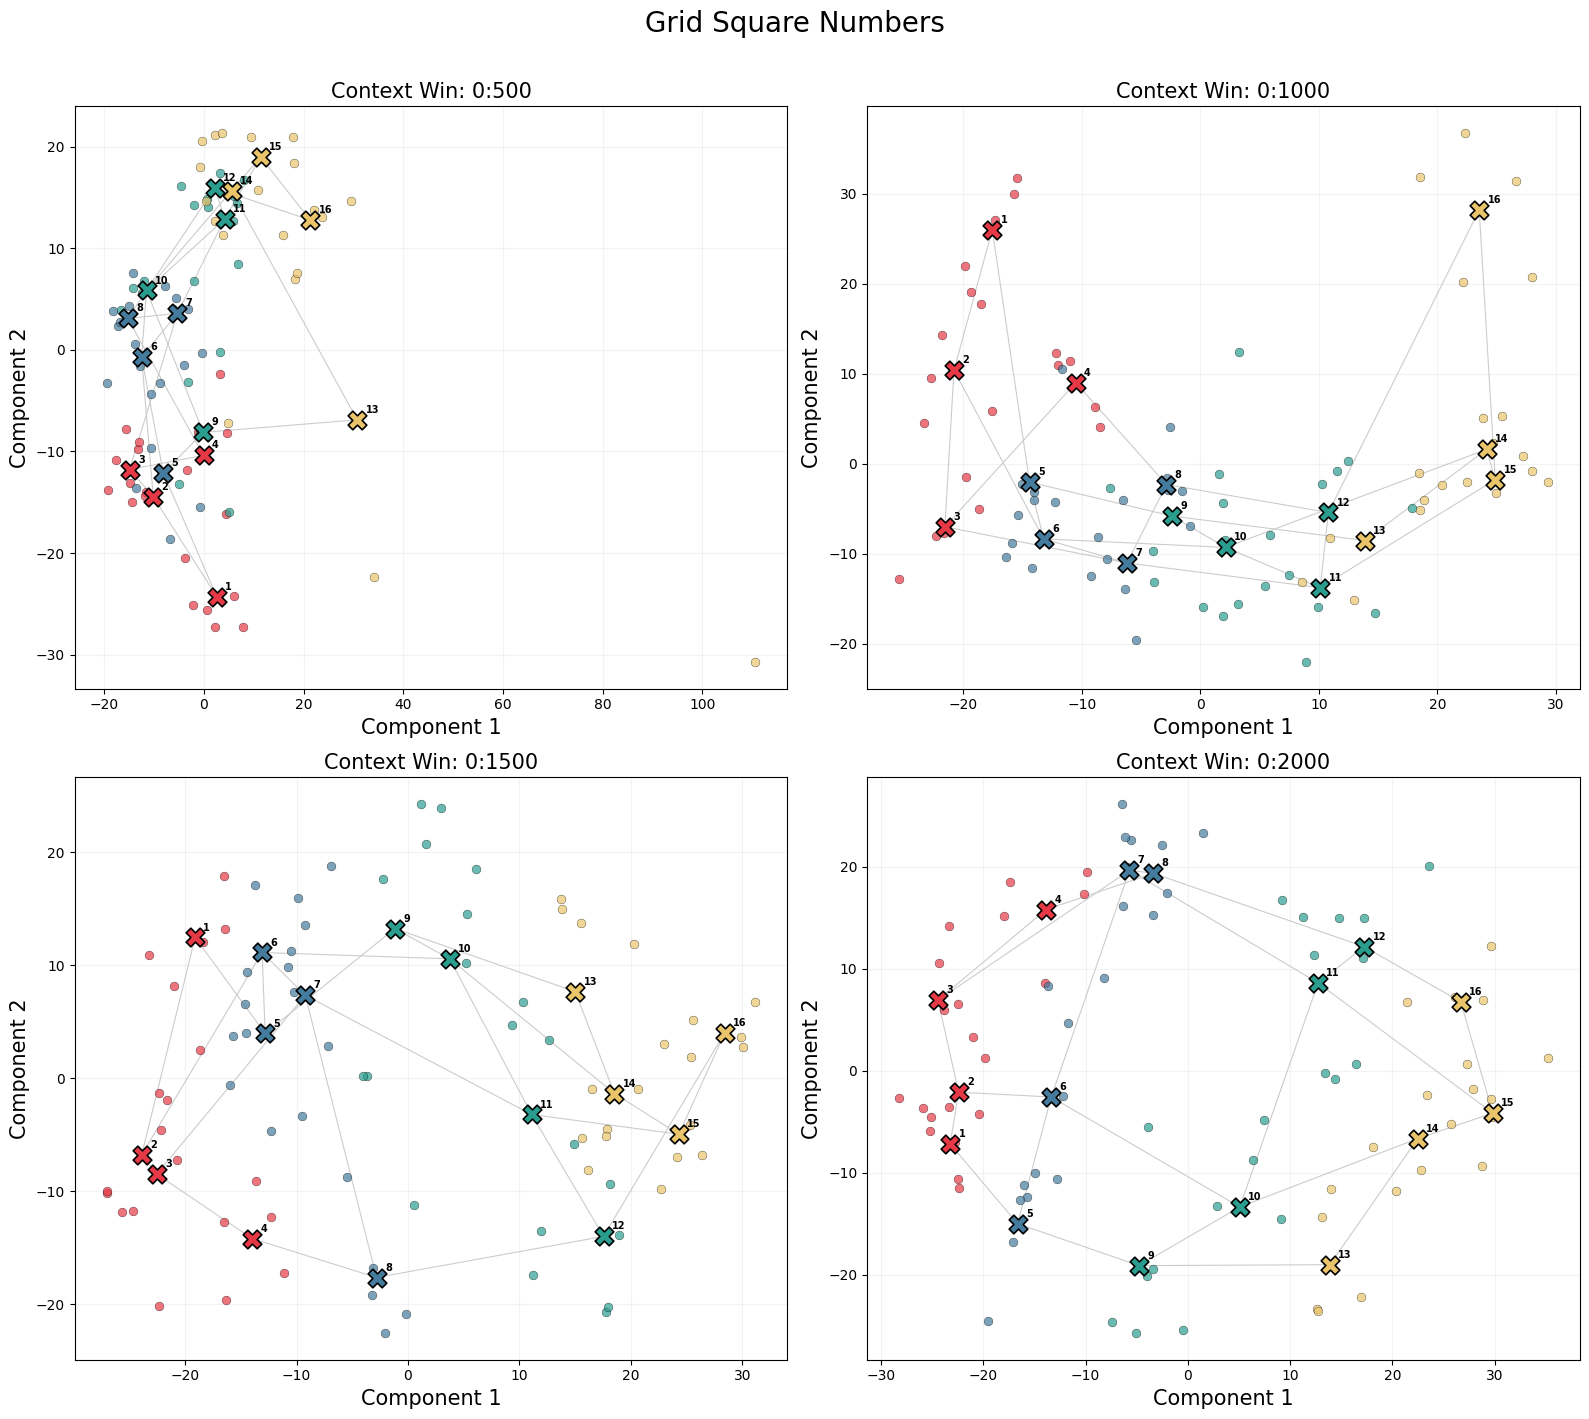

Grid - #nodi: 16 #archi: 24
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '12' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '16' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '10' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '13' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_le

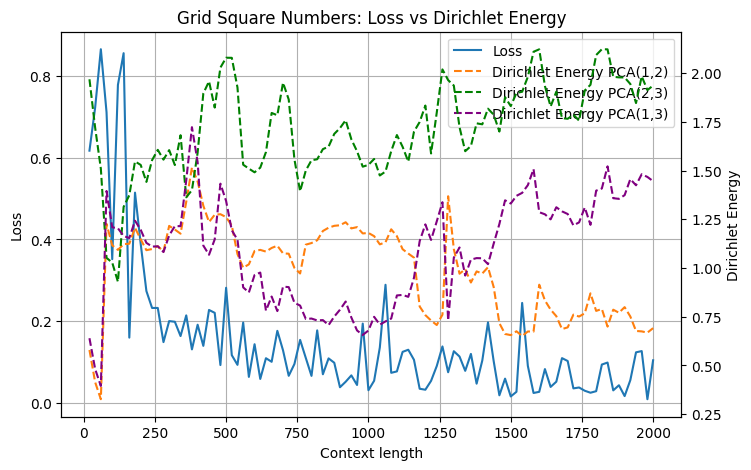

In [21]:
directory = "grid_square_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1500, 2000]

pc_to_plot = (0, 1)  # PCA components to plot
k_last = 5

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Shuffled Square Numbers

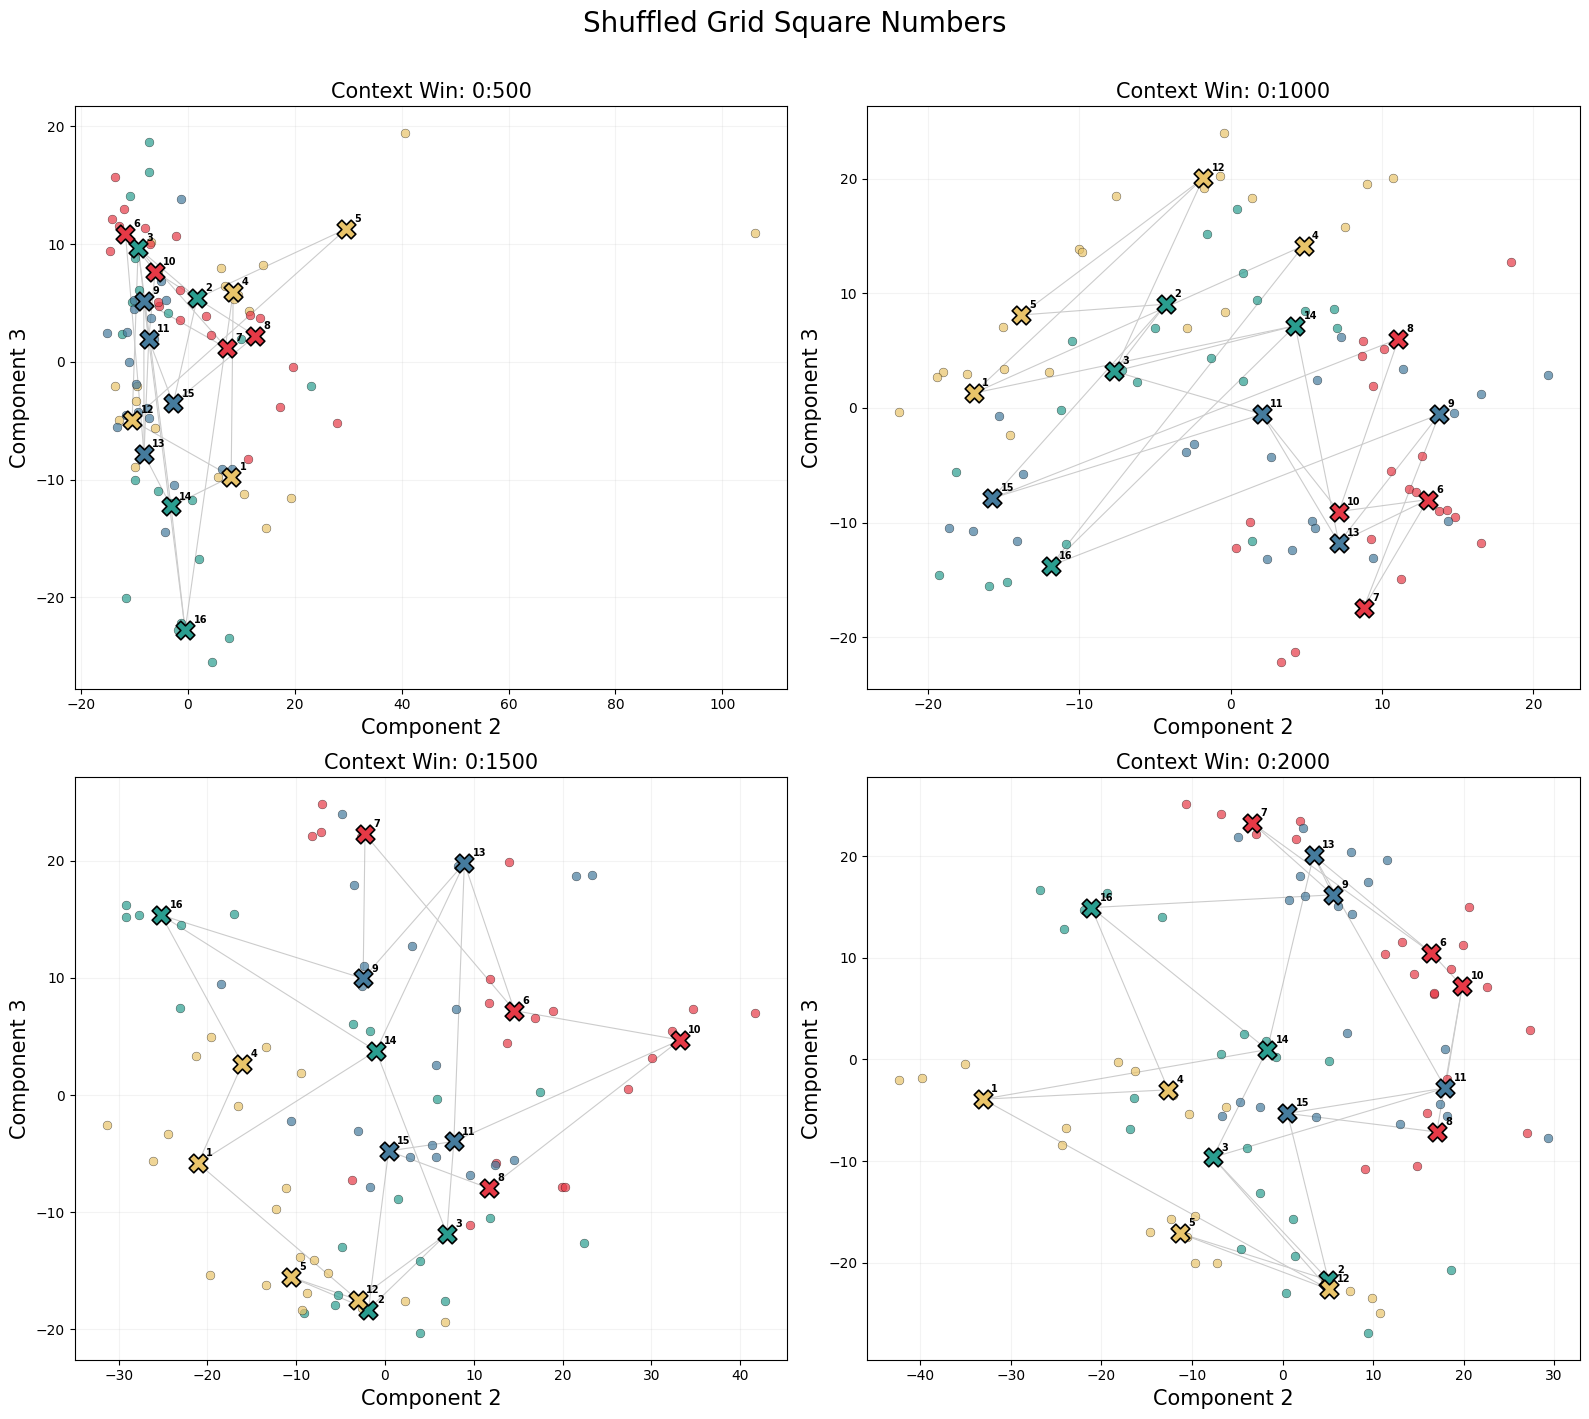

Grid - #nodi: 16 #archi: 24
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '16' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '12' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '1' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '3' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '4' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '5' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '11' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40

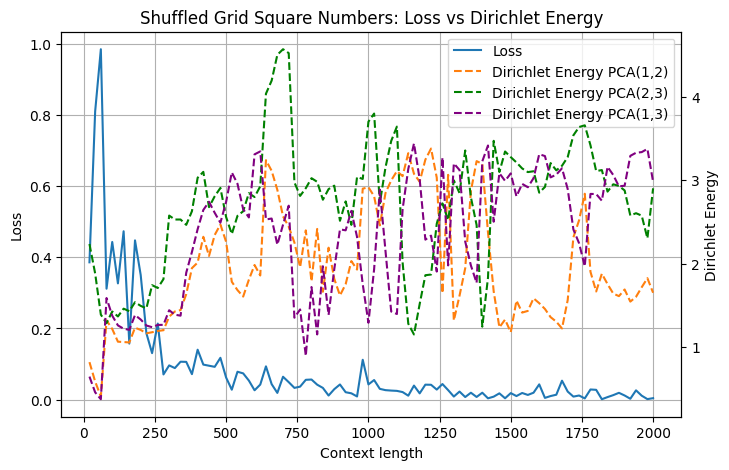

In [22]:
directory = "shuffled_grid_square_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1500, 2000]

k_last = 5

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,0:2]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=True)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Square Words

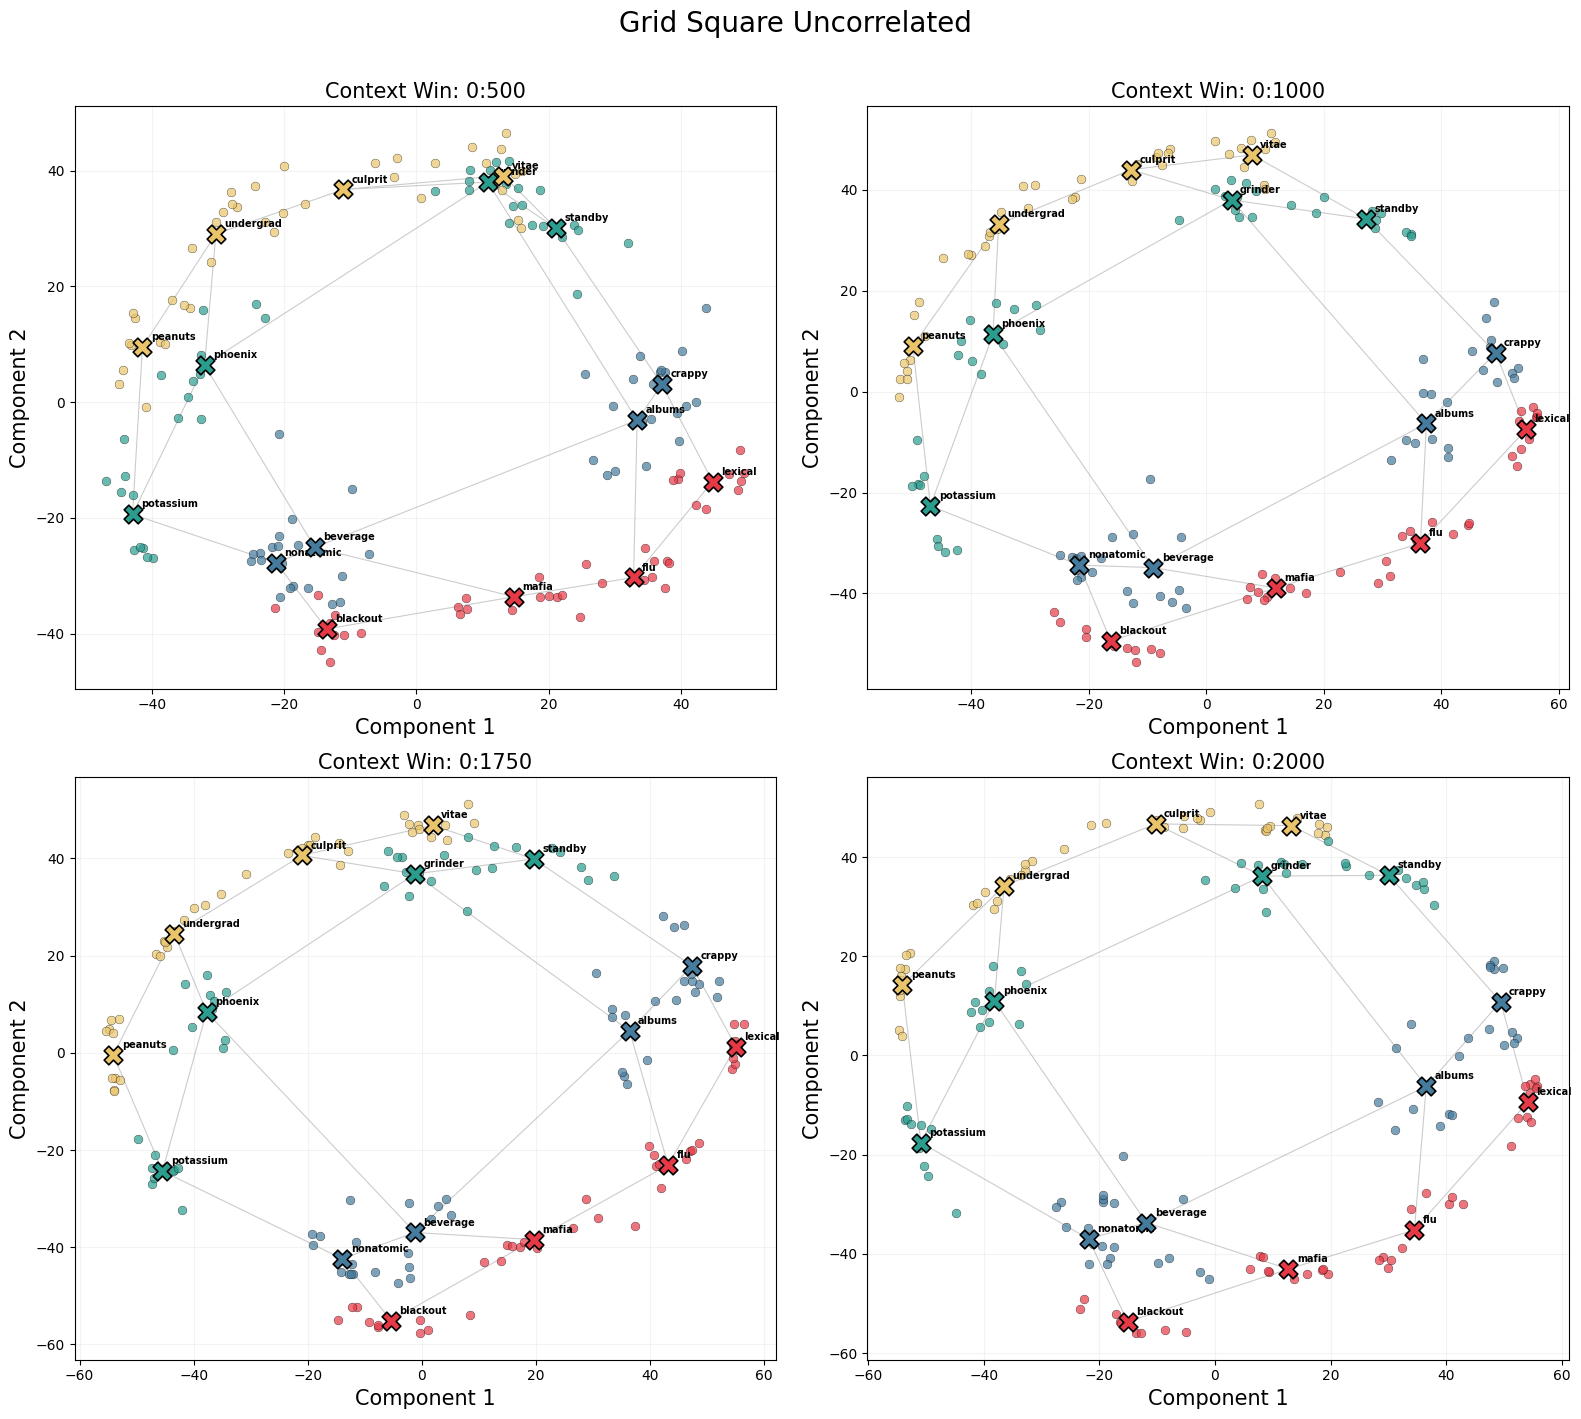

Grid - #nodi: 16 #archi: 24
[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='vit')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'peanuts' has only 3 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'potassium' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'vitae' has only 1 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'nonatomic' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'standby' has only 1 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 1 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'beverage' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'undergrad' has only 3 occurrences i

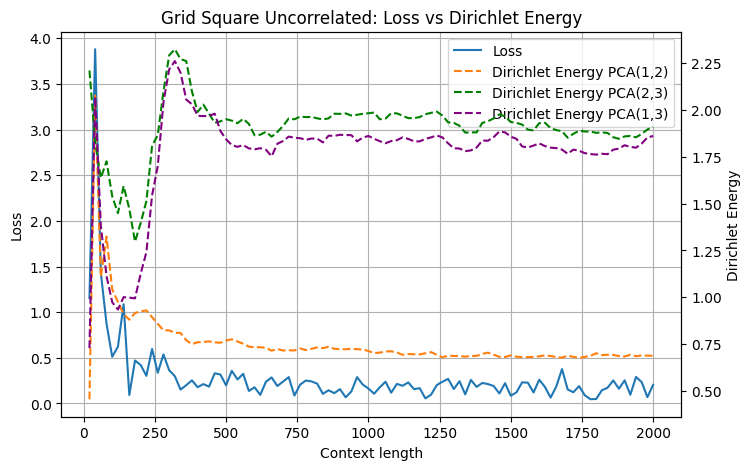

In [23]:
directory = "grid_square_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1750, 2000]

k_last = 10

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,0:2]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Days

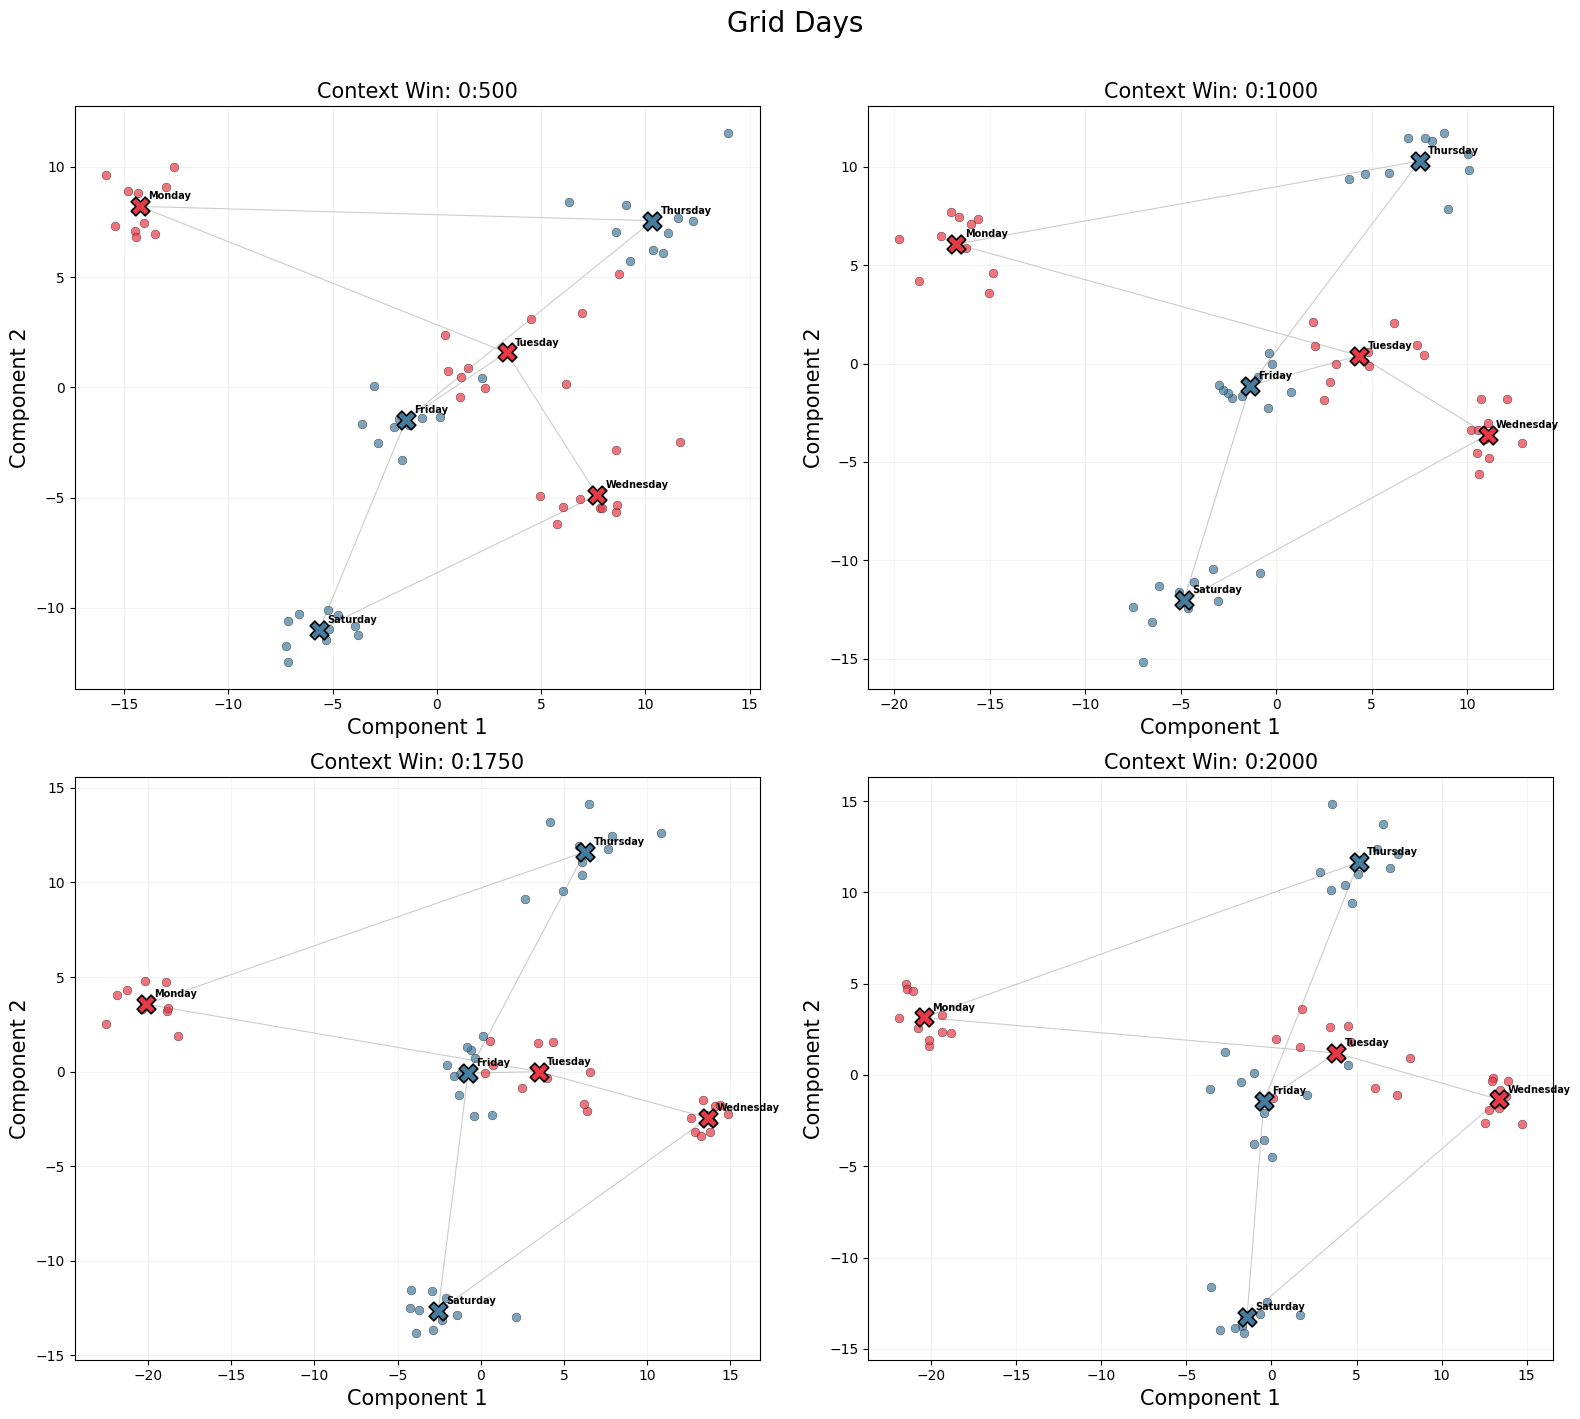

Grid - #nodi: 6 #archi: 7
[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Friday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Friday' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 7 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Saturday' has only 5 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Thursday' has only 2 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 9 occurrences in [0:40] (requested 10

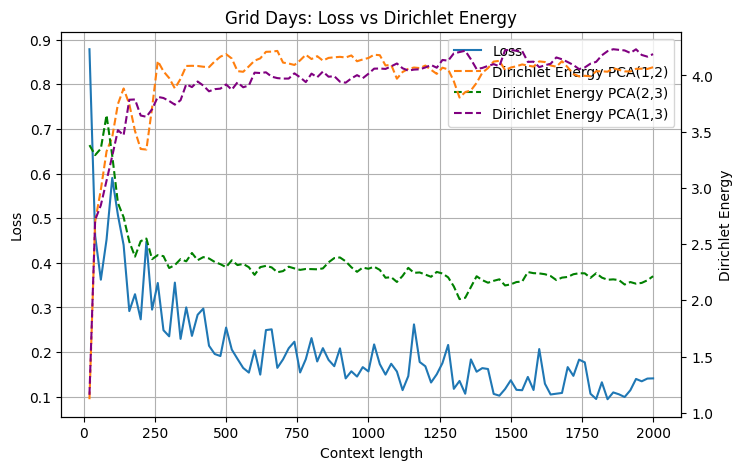

In [24]:
directory = "grid_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1750, 2000]

k_last = 10

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,1:3]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Shuffled Days

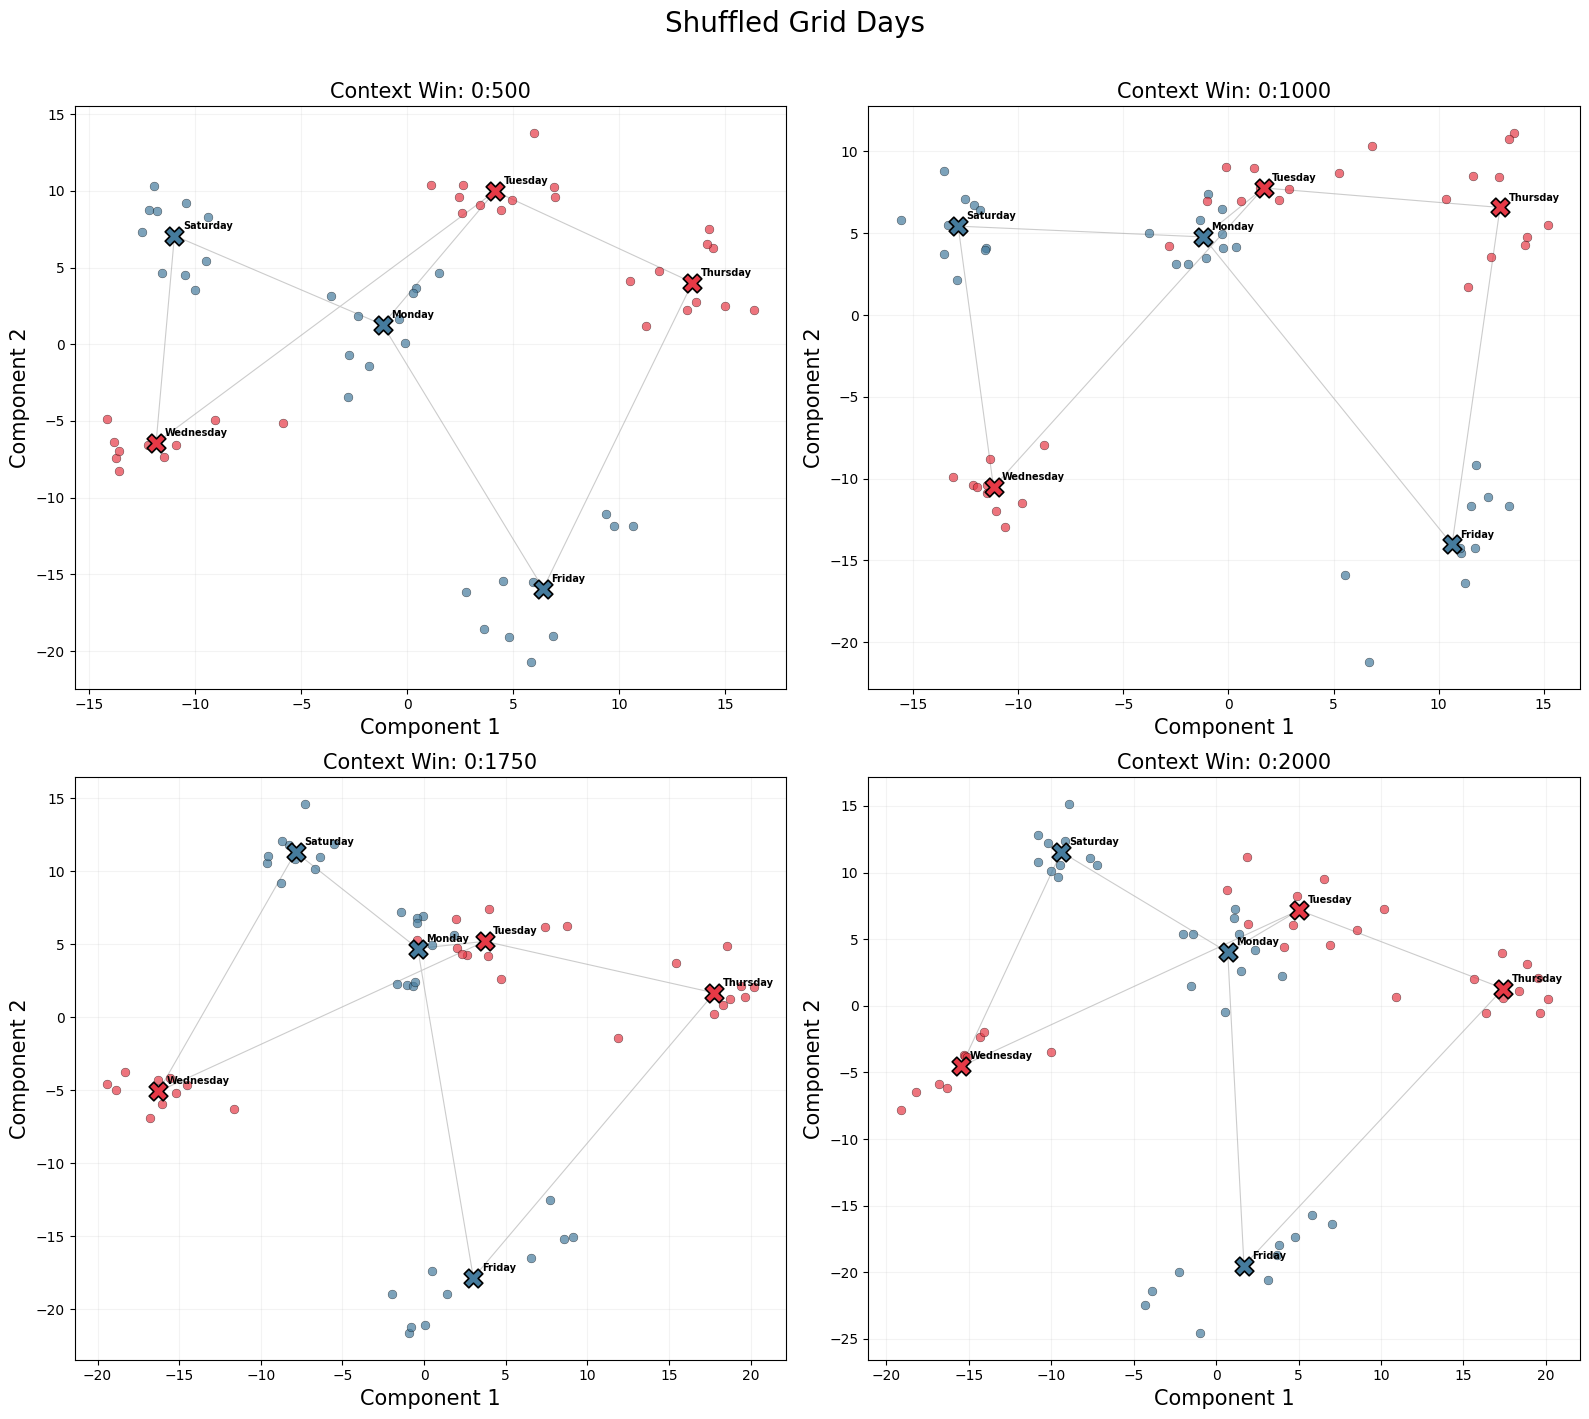

Grid - #nodi: 6 #archi: 7
[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Monday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Thursday' has only 3 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 2 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 7 occurrences in [0:20] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Saturday' has only 5 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Thursday' has only 5 occurrences in [0:40] (requested 10)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 9 occurrences in [0:40] (requested 

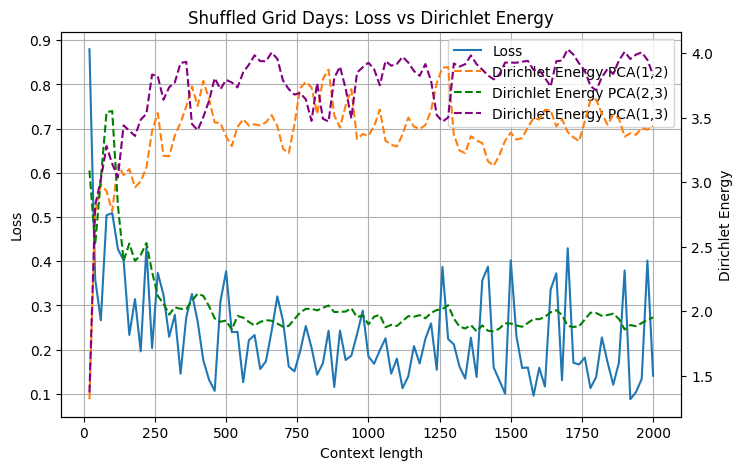

In [25]:
directory = "shuffled_grid_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "grid"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ctx = 2000
CTX_LENS = [500, 1000,1750, 2000]

k_last = 10

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,1:3]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

# Circles

## Ordered Numbers: Random Walk

  [] Warning: token '8' has only 4 occurrences in [0:500] (requested 5)
  [] Warning: token '9' has only 2 occurrences in [0:500] (requested 5)
  [] Warning: token '10' has only 3 occurrences in [0:500] (requested 5)
  [] Warning: token '8' has only 4 occurrences in [0:1000] (requested 5)
  [] Warning: token '9' has only 2 occurrences in [0:1000] (requested 5)
  [] Warning: token '10' has only 4 occurrences in [0:1000] (requested 5)


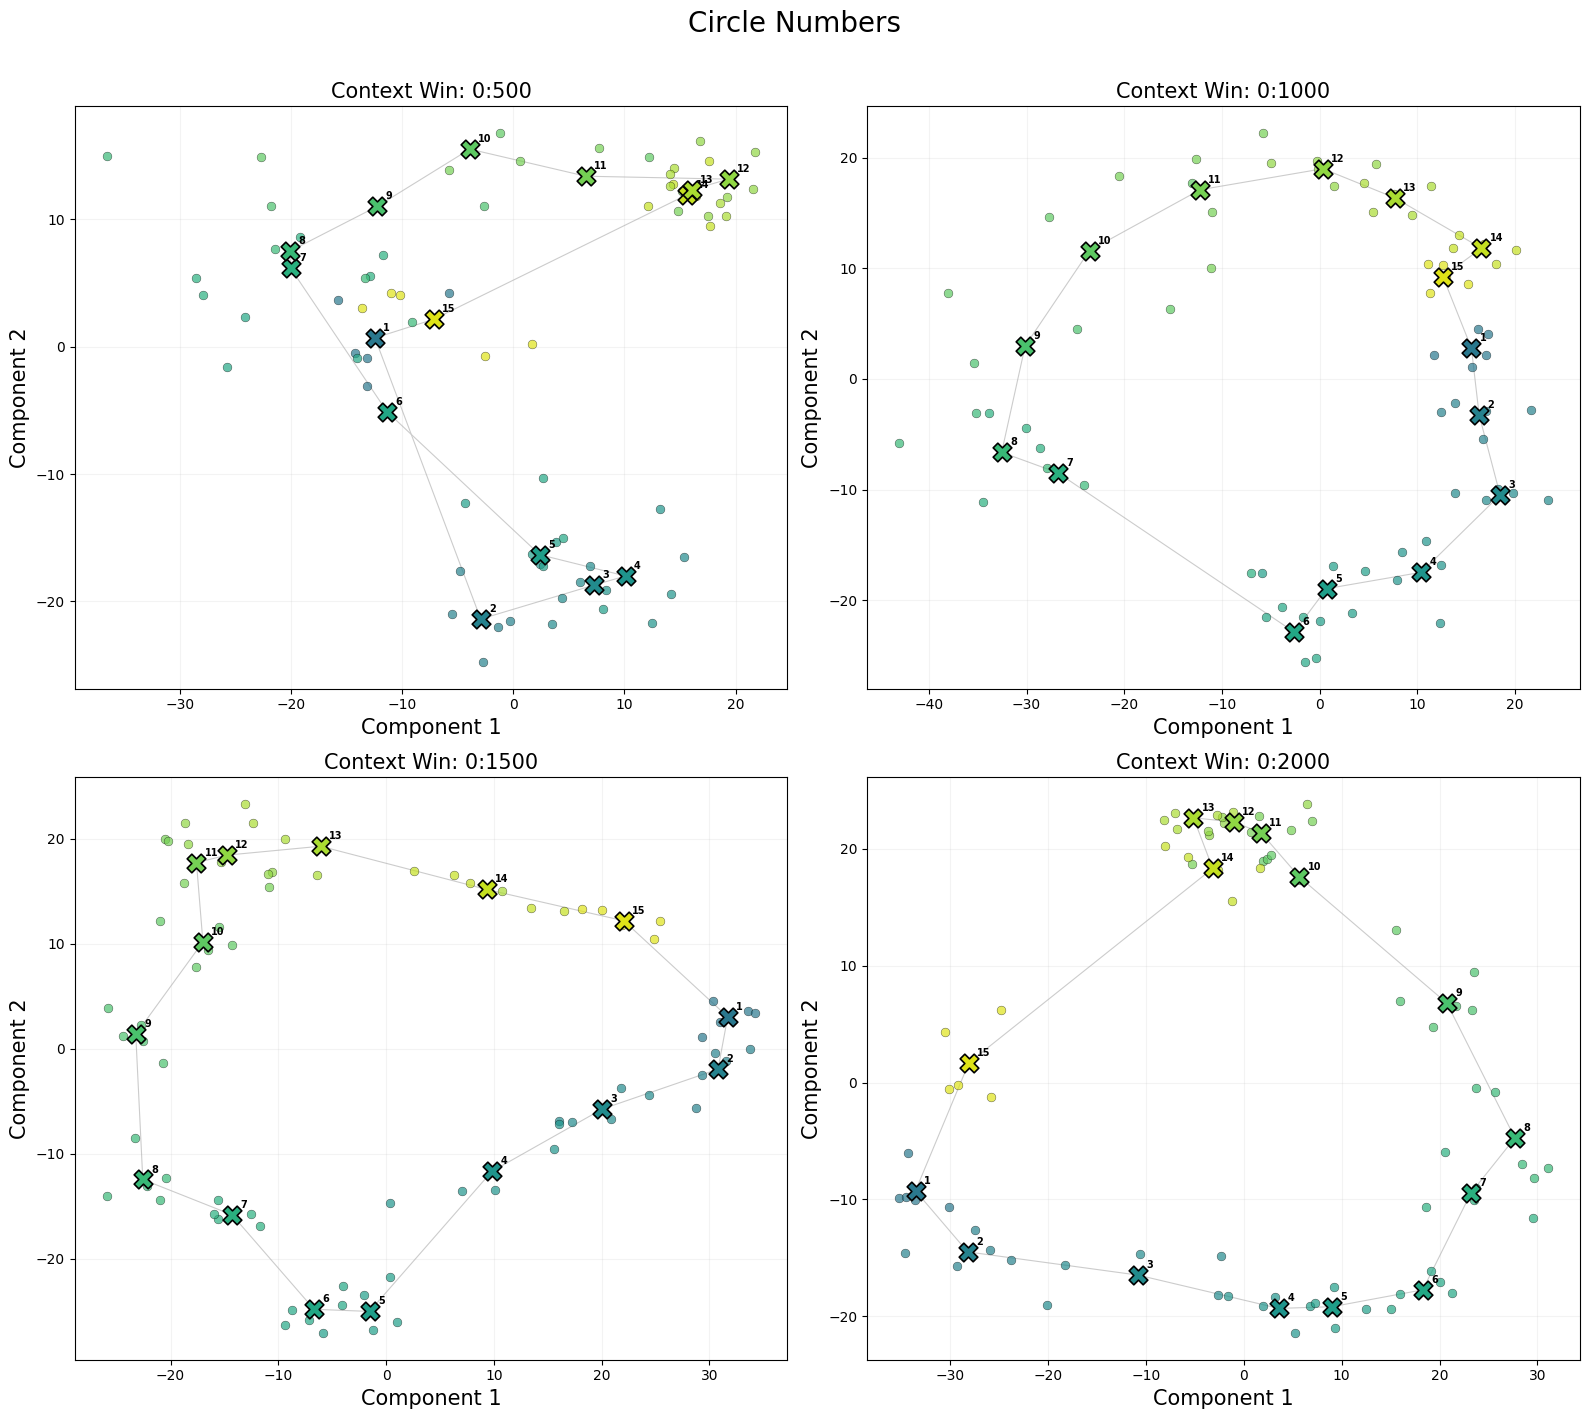

Grid - #nodi: 15 #archi: 15
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '1' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '3' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '4' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '5' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '6' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40,

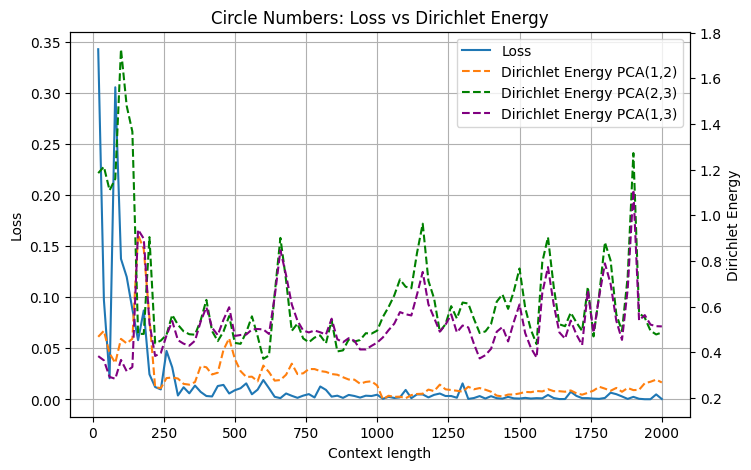

In [27]:
directory = "circle_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

CTX_LENS = [500, 1000,1500, 2000]

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False, second_components=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Shuffled Numbers: Random Walk

  [] Warning: token '3' has only 4 occurrences in [0:500] (requested 5)
  [] Warning: token '4' has only 3 occurrences in [0:500] (requested 5)
  [] Warning: token '10' has only 2 occurrences in [0:500] (requested 5)
  [] Warning: token '3' has only 4 occurrences in [0:1000] (requested 5)
  [] Warning: token '4' has only 4 occurrences in [0:1000] (requested 5)
  [] Warning: token '10' has only 2 occurrences in [0:1000] (requested 5)


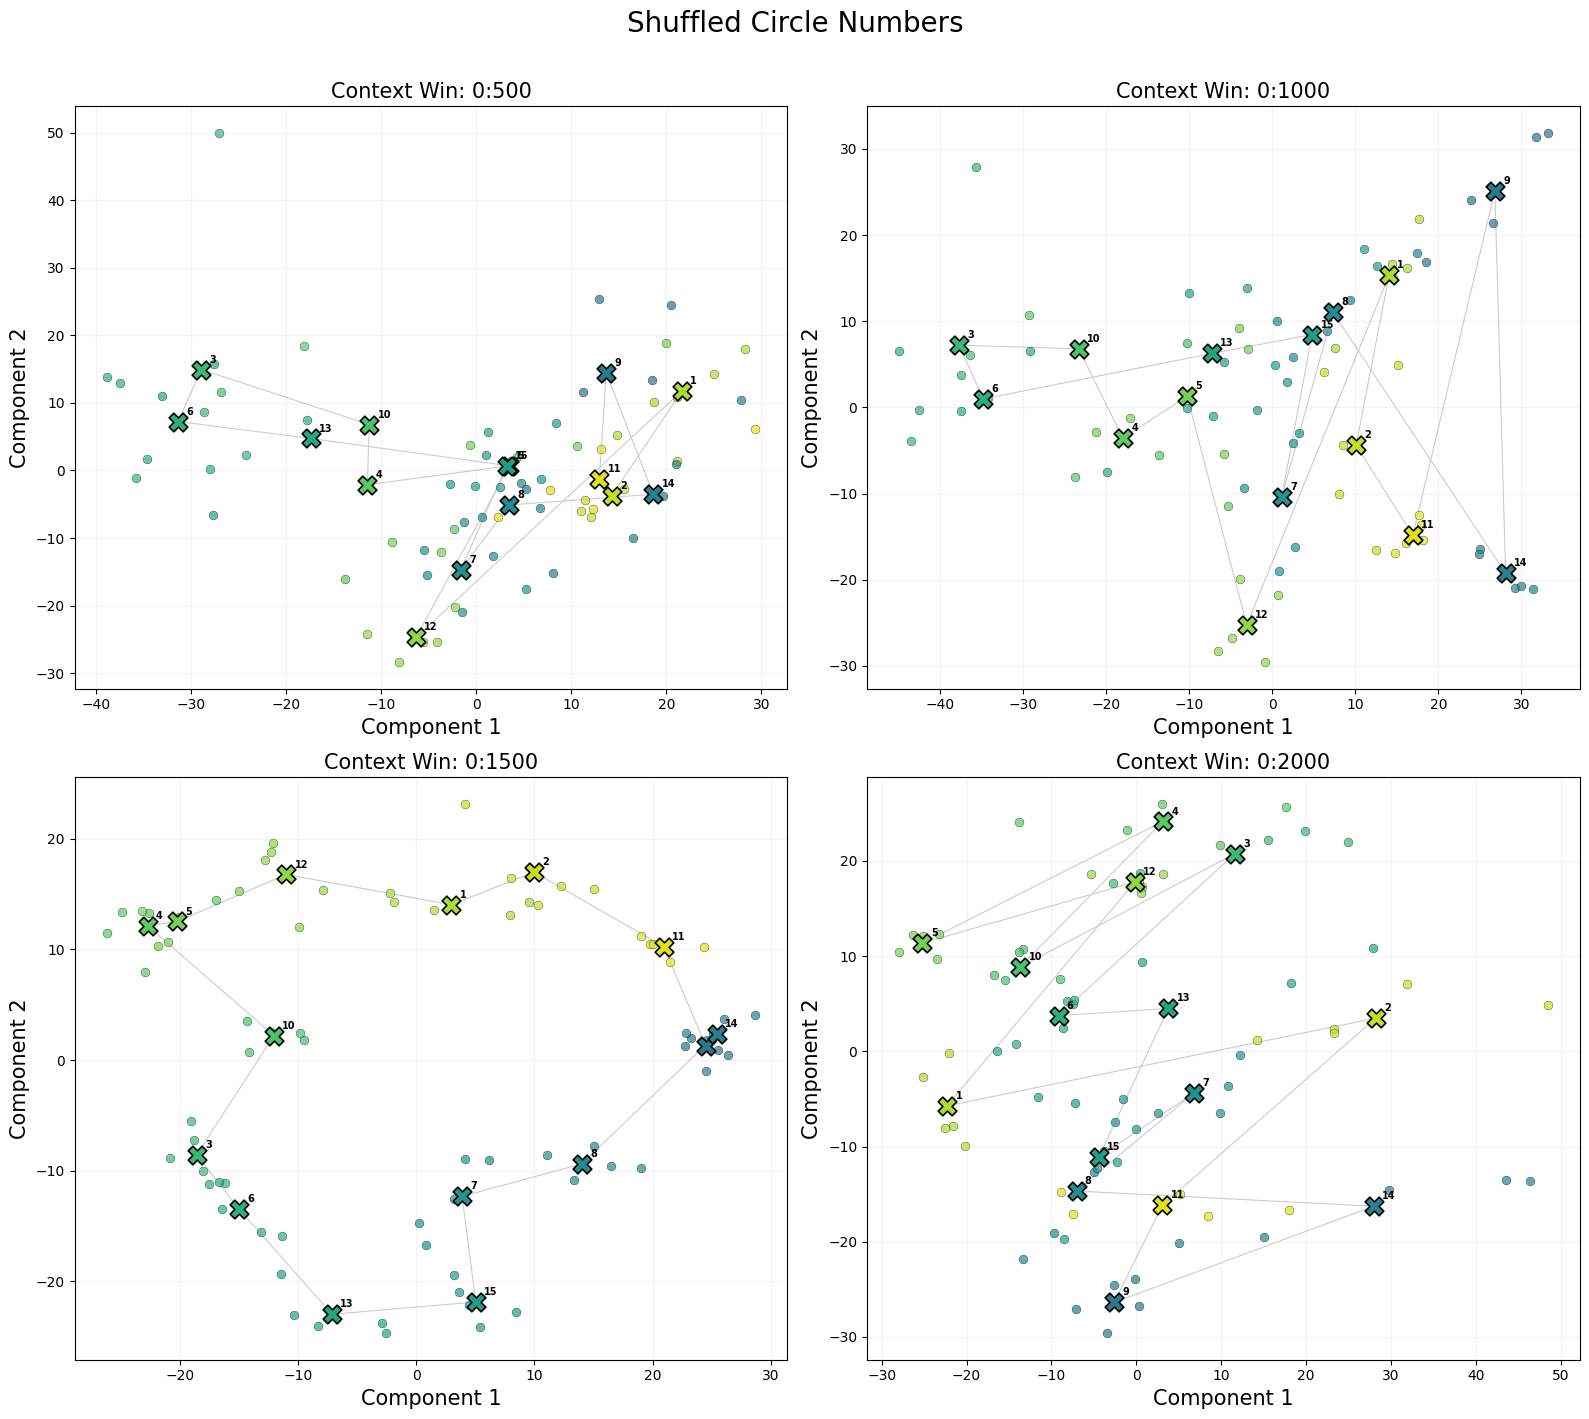

Grid - #nodi: 15 #archi: 15
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '11' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '7' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '8' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=4

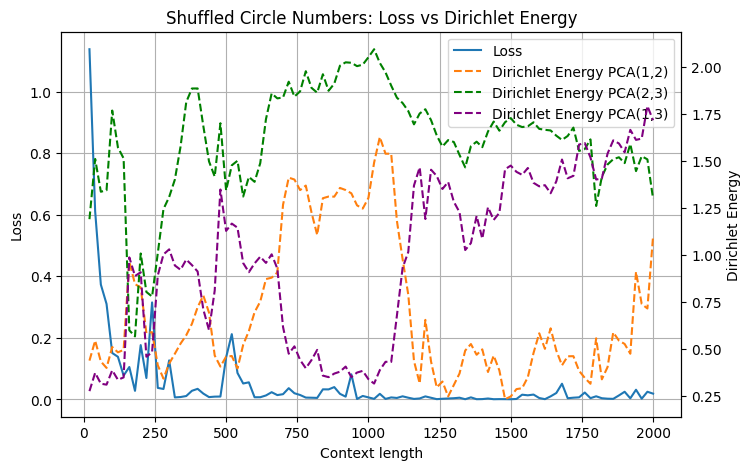

In [28]:
directory = "shuffled_circle_numbers" 
VOCAB_PATH  = Path("../data/numbers_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

CTX_LENS = [500, 1000,1500, 2000]

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", 
                             only_centroid=False, second_components=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Words: Random Walk

  [] Warning: token 'potassium' has only 2 occurrences in [0:500] (requested 5)
  [] Warning: token 'crappy' has only 4 occurrences in [0:500] (requested 5)
  [] Warning: token 'phoenix' has only 3 occurrences in [0:500] (requested 5)


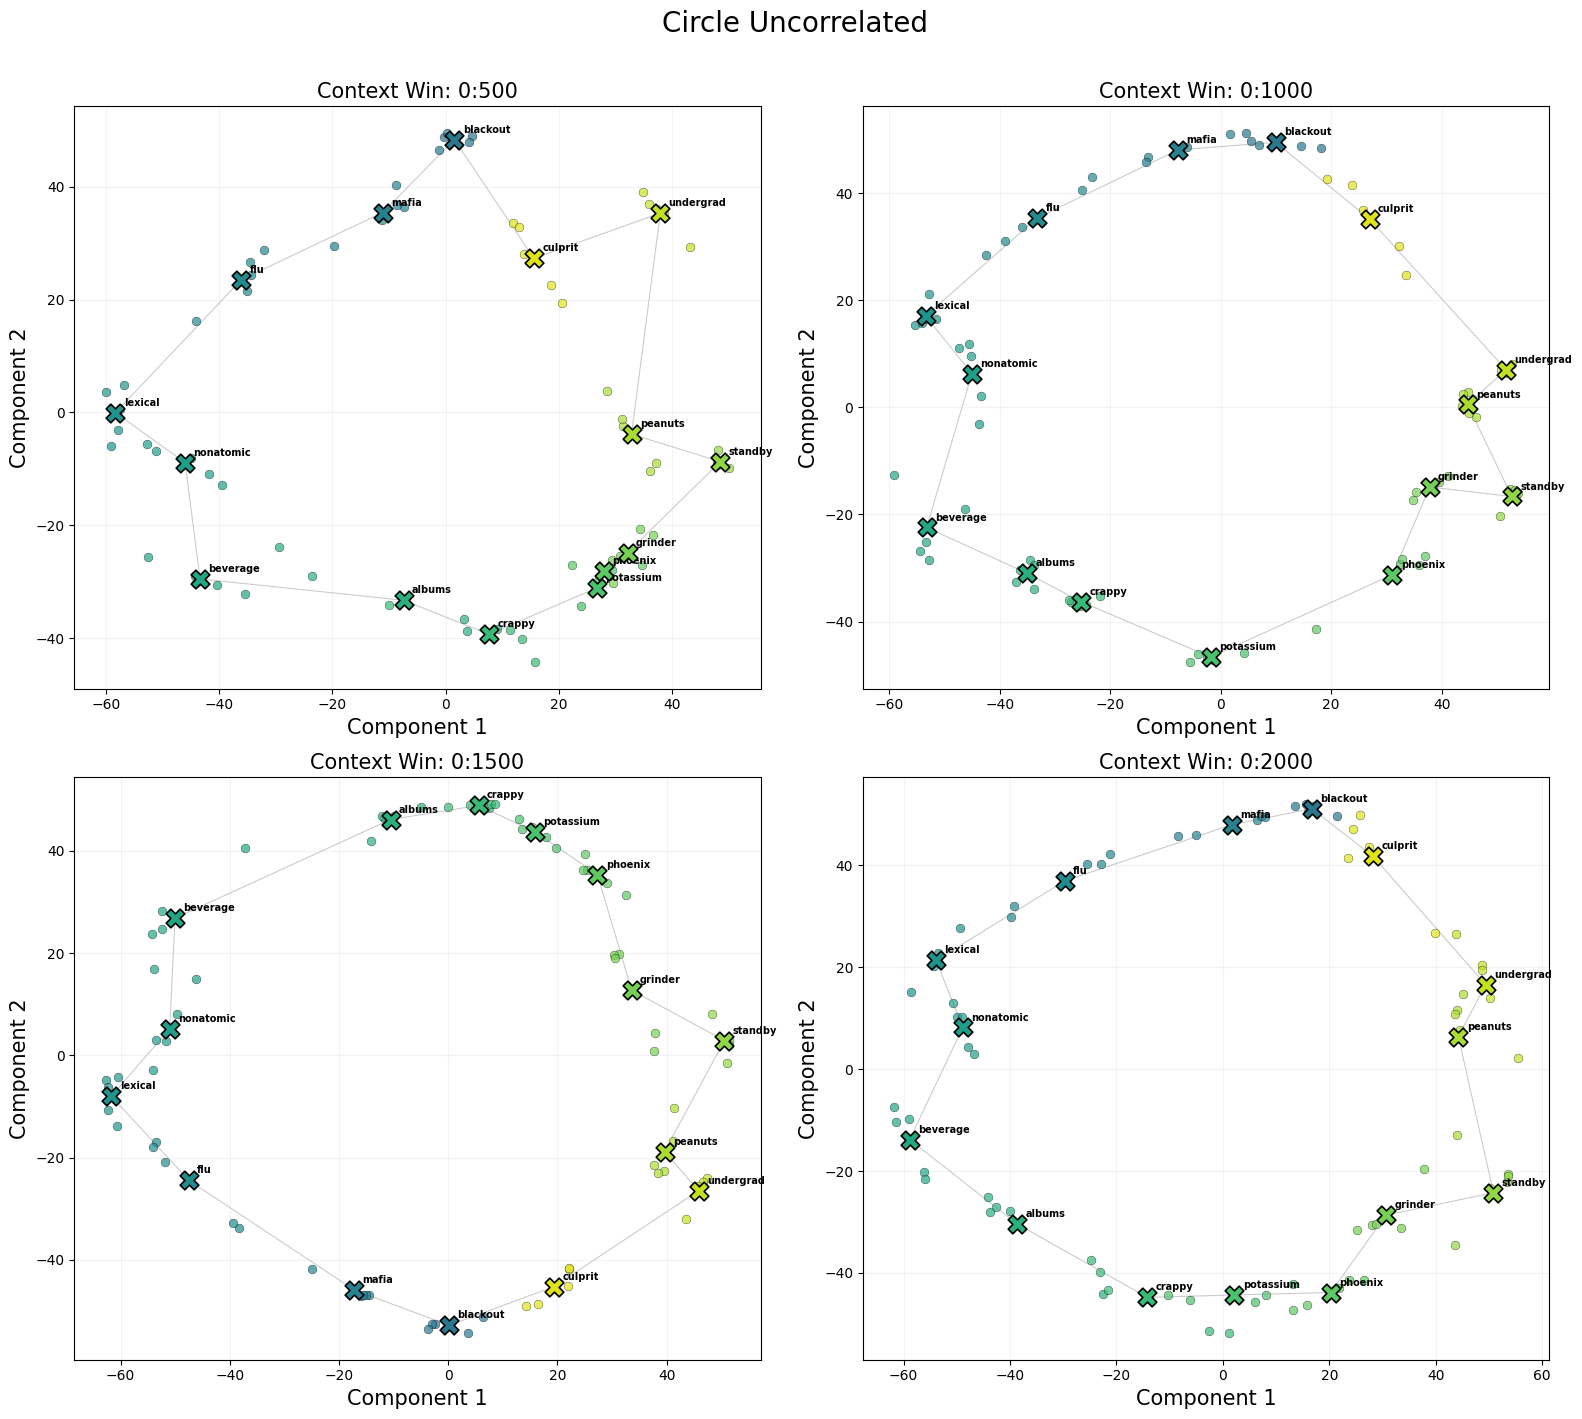

Grid - #nodi: 15 #archi: 15
[WARN] Record non valutabile (pos 2, line 0): observed_token_not_in_graph (observed_raw='under')
[WARN] Record non valutabile (pos 12, line 0): None (observed_raw='beverage')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'blackout' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'nonatomic' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'mafia' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'flu' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'culprit' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'beverage' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'blackout' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=

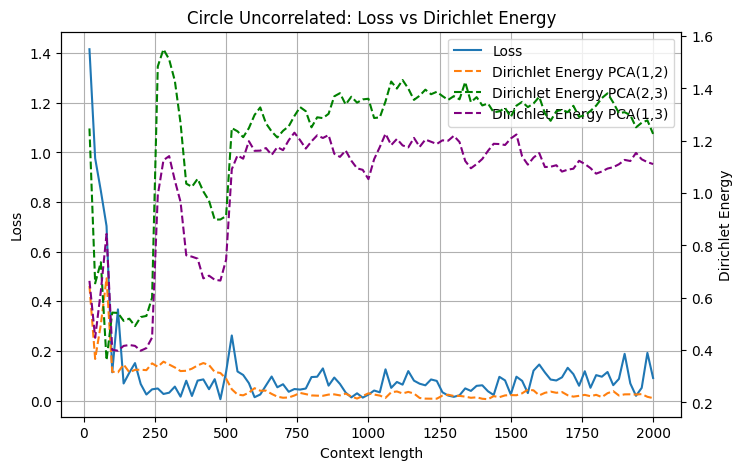

In [29]:
directory = "circle_uncorrelated" 
VOCAB_PATH  = Path("../data/words_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

CTX_LENS = [500, 1000,1500, 2000]

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Days: Random Walk

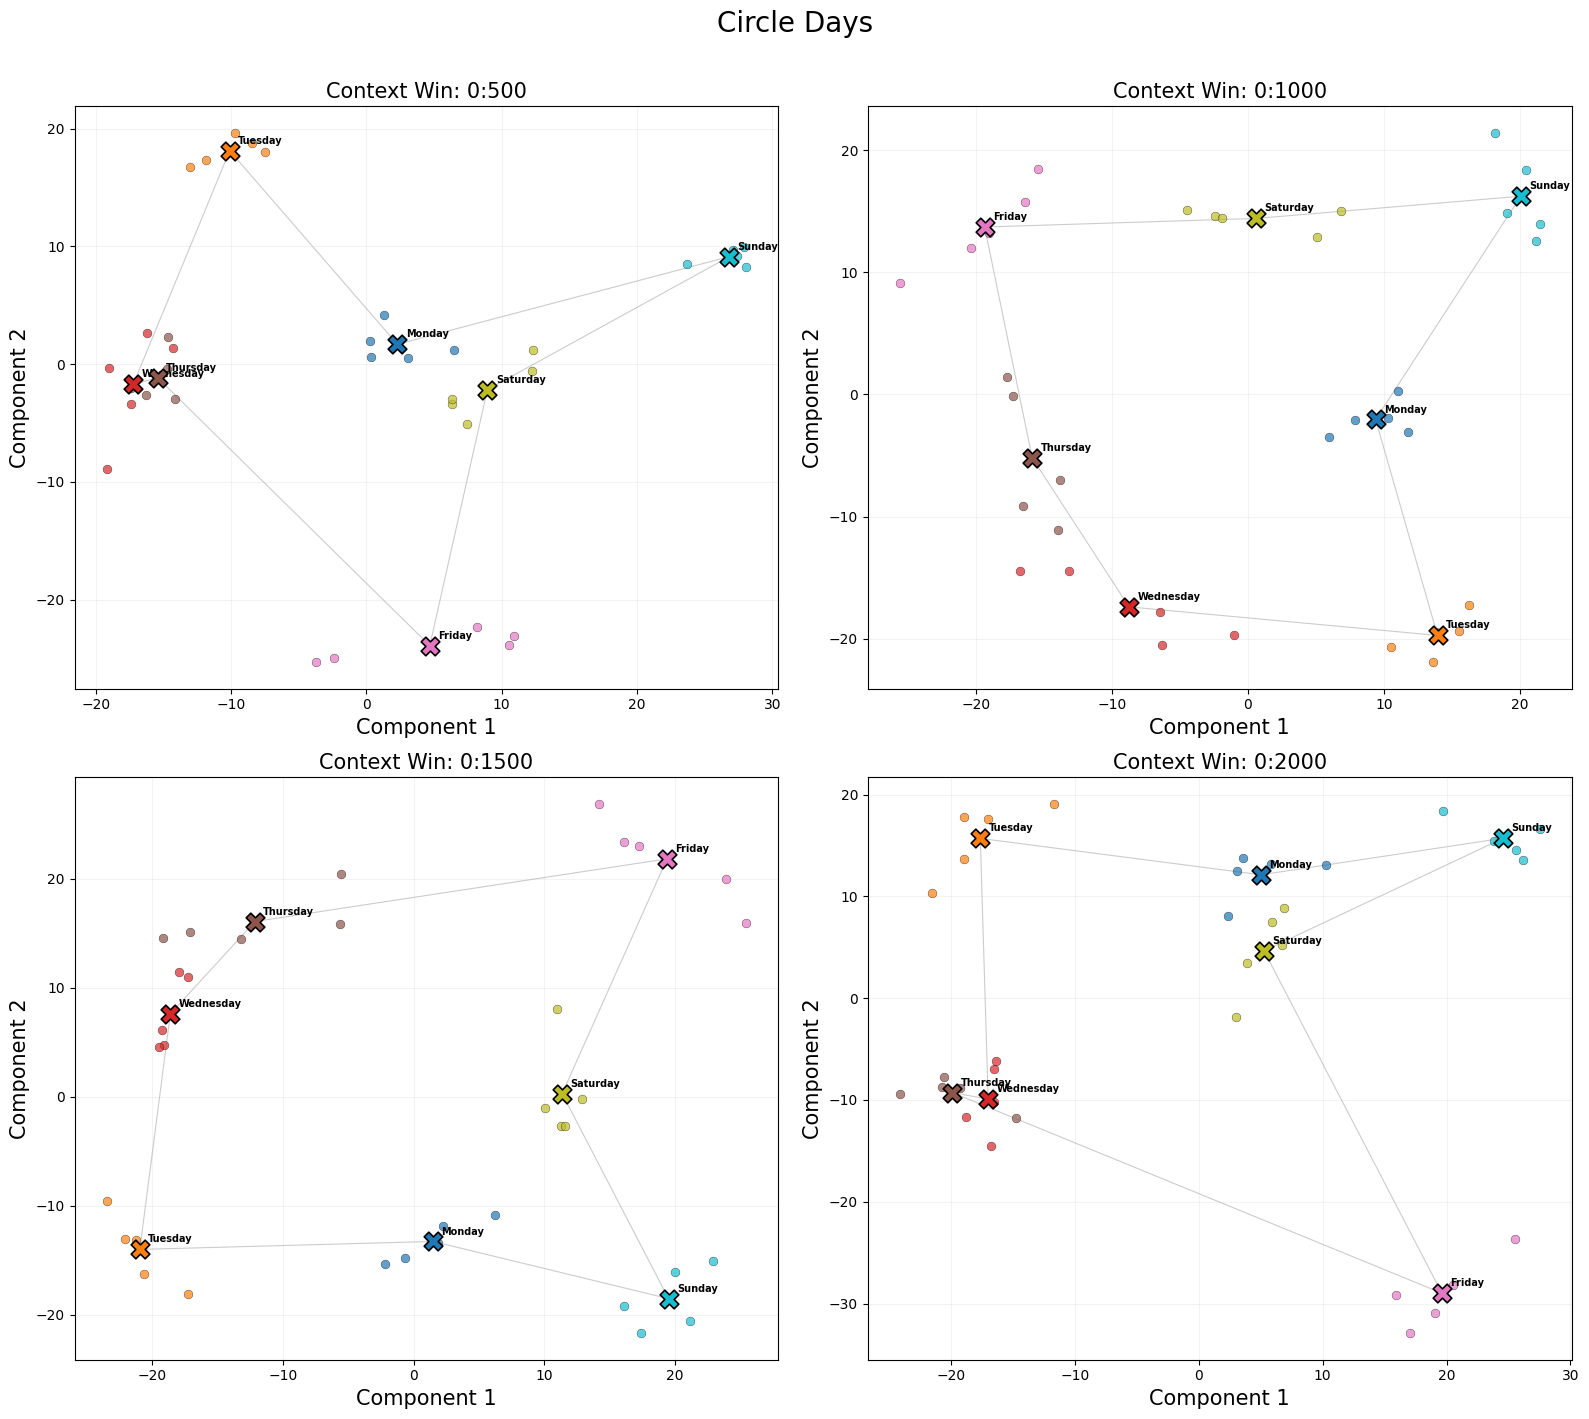

Grid - #nodi: 7 #archi: 7
[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Sunday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Thursday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Sunday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Wednesday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Tuesday' has only 3 occurrences in [0:40] (requested 5)
  [ctx=

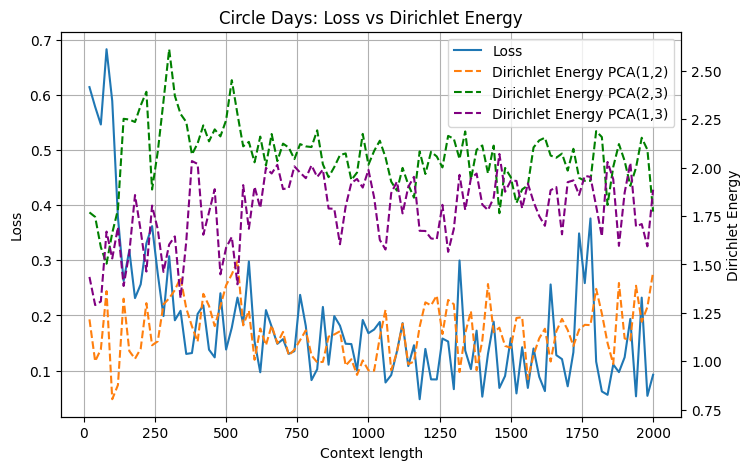

In [30]:
directory = "circle_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

CTX_LENS = [500, 1000,1500, 2000]

k_last = 5
pc_to_plot = (0, 1)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()

## Shuffled Days: Random Walk

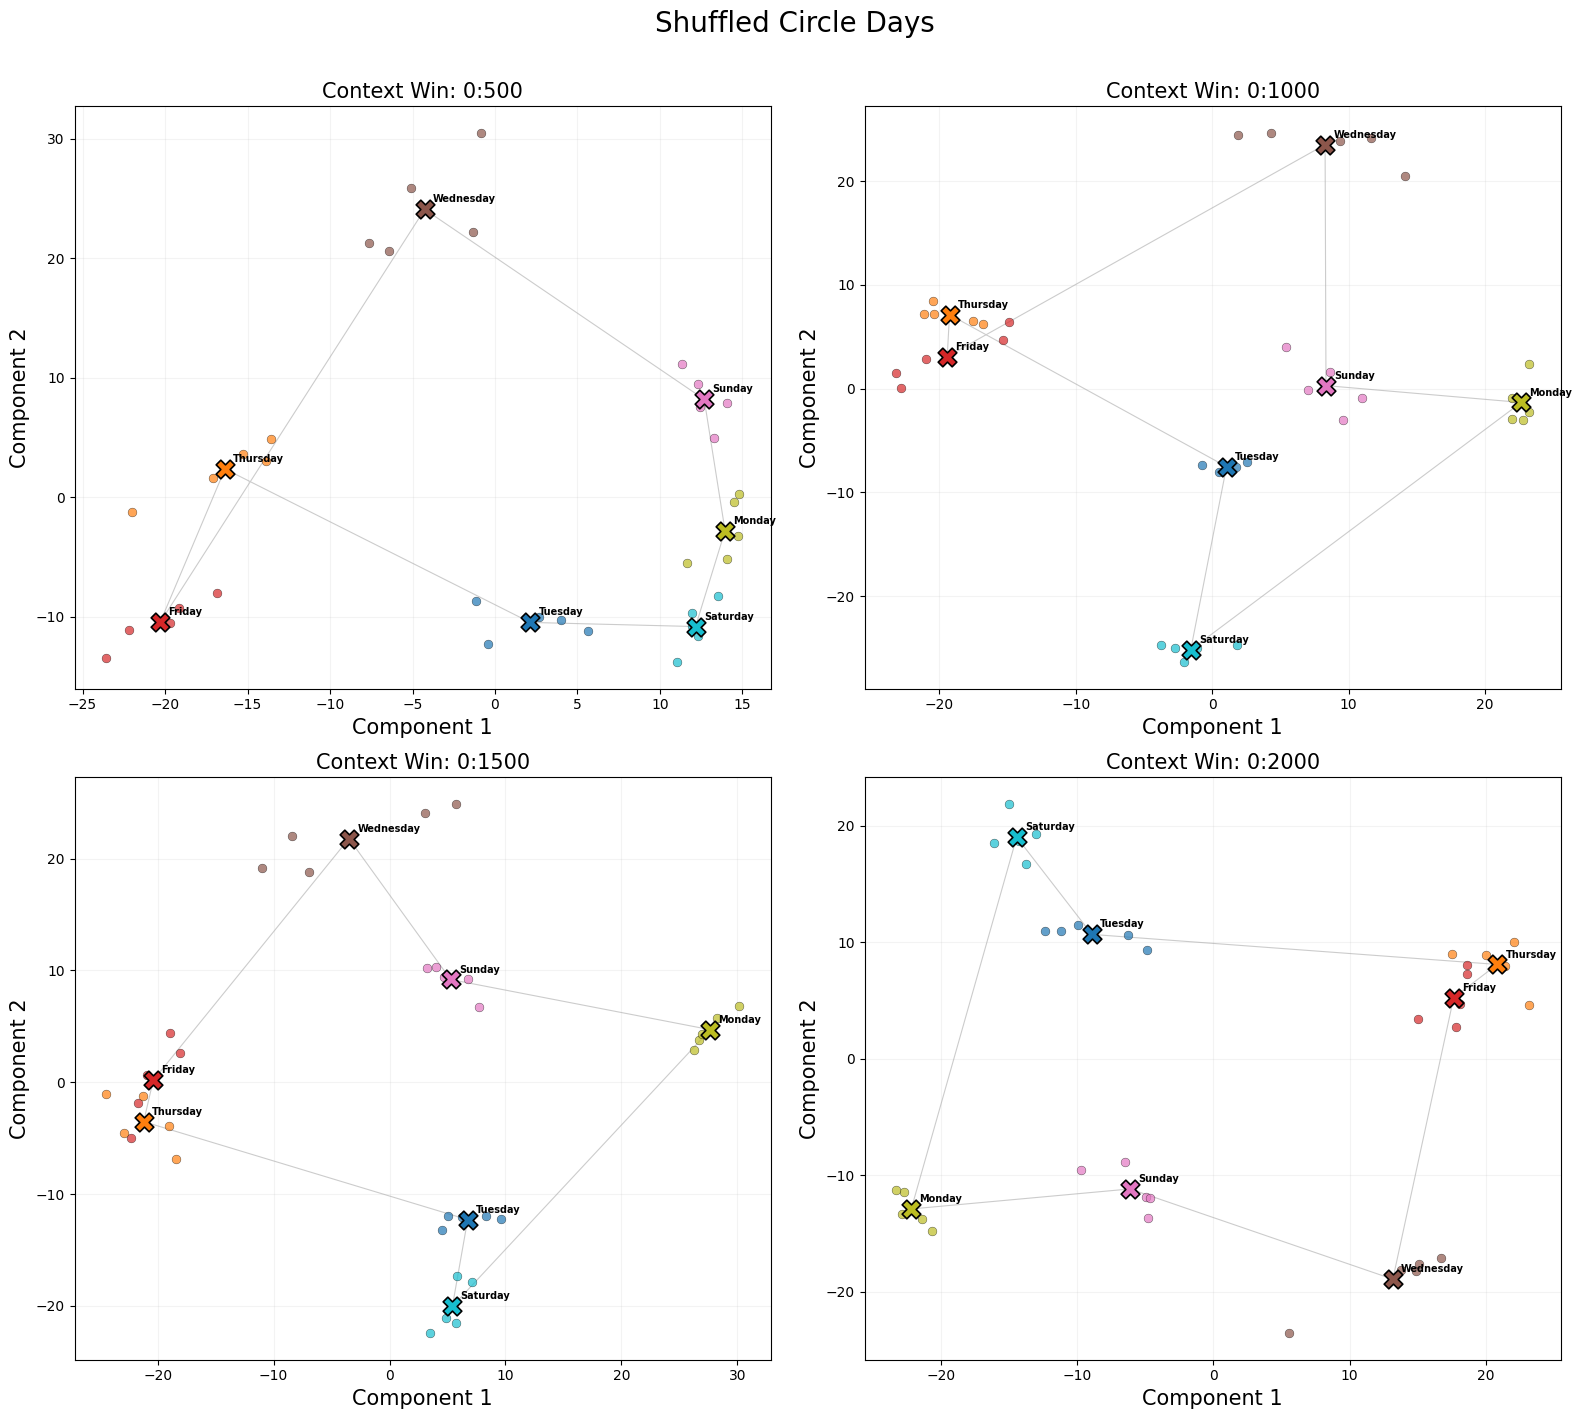

Grid - #nodi: 7 #archi: 7
[WARN] Record non valutabile (pos 2, line 0): None (observed_raw='Saturday')
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Saturday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Thursday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Wednesday' has only 4 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Friday' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Monday' has only 3 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token 'Tuesday' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Thursday' has only 3 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token 'Friday' has only 2 occurrences in [0:40] (requested 5)
  [ctx=

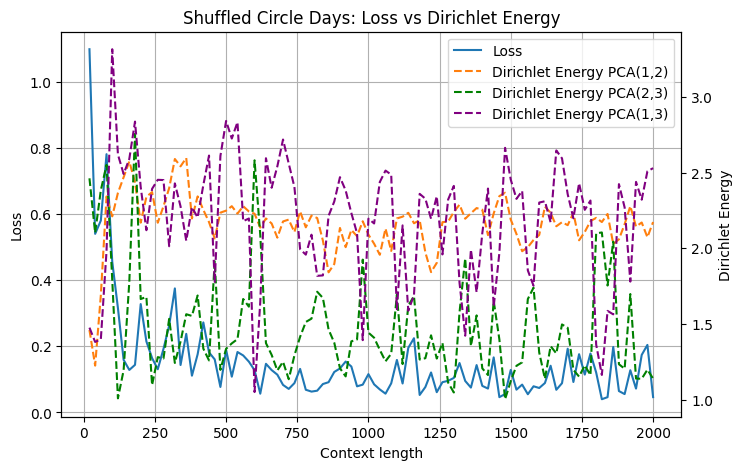

In [31]:
directory = "shuffled_circle_days" 
VOCAB_PATH  = Path("../data/days_dict.txt")
graph_kind = "cycle"

EMB_DIR     = Path(f"../embeddings/{directory}")
STRUCT_PATH = Path(f"../data/one_random_walk/{directory}/structure.txt")

CTX_LENS = [500, 1000,1500, 2000]

k_last = 5
pc_to_plot = (1, 2)

hp_tree = Plotter(
    VOCAB_PATH,
    STRUCT_PATH,
    EMB_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

embs_file = EMB_DIR / f"reprs_{directory}_line000000_layer32.pt"
ids_np, emb_np = load_embeddings_pt(embs_file)

for ax, win_len in zip(axes.flat, CTX_LENS):

    filtered_ids, filtered_embs = _window_and_filter(ids_np, emb_np, hp_tree.id_to_word, 
                                                     k=k_last, t_start=0, t_end=win_len)
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(filtered_embs)[:,[pc_to_plot[0], pc_to_plot[1]]]

    hp_tree.plot_reduced_emb(ax, pca_result, filtered_ids, title=f"Context Win: 0:{win_len}", only_centroid=False)

fig.suptitle(directory.replace("_", " ").title(),
             fontsize=20, y=1.01)
fig.tight_layout()
# fig.savefig(f"../plots/pca_{directory}.png", dpi=300, bbox_inches='tight')
plt.show()

G = load_graph_from_txt(STRUCT_PATH, kind=graph_kind)
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

probs_file = EMB_DIR / f"topk_step10_{directory}.pt"

# Carica records top-k
data = torch.load(probs_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE ENERGY

WIN = 20
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=PCA_K,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy23 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

shuffled_tree_energy13 = compute_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=STRUCT_PATH,
    EMB_DIR=EMB_DIR,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=k_last,
    MIN_NODES=MIN_NODES,
    pt_filename=embs_file.name,
    graph_kind=graph_kind,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"{directory.replace('_', ' ').title()}: Loss vs Dirichlet Energy")
plt.show()